# Fixed leakage in feature selection. Used smote correctly. Did train test split correctly.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB



In [2]:

df = pd.read_excel("/content/bdhs2022_final_analysis_dataset_new_under_five.xlsx")

In [3]:
df['mother_bmi'].describe()

,mother_bmi
count,3935.000000
mean,23.163972
std,4.207058
min,13.000000
25%,20.040000
50%,22.810000
75%,25.725000
max,43.710000


In [4]:
df.head()

,age_months,mother_edu,birth_order,mother_occ,children_ever_born,father_edu,division,mother_age,mother_bmi,skilled_birth,toilet_improved,has_tv_clean,has_electricity_clean,reads_newspaper_clean,wants_more_children,wealth_index_clean,stunted,haz
0,46,2,1.0,0,1.0,2,1,22,24.88,0,1,1,1,0,1,5,0,1.15
1,46,2,1.0,0,1.0,2,1,21,29.06,0,1,1,1,0,1,3,0,-0.34
2,49,3,3.0,0,3.0,3,1,32,25.29,0,1,1,1,0,0,5,0,-0.22
3,32,3,2.0,1,2.0,2,1,26,21.70,1,1,1,1,1,0,4,0,0.08
4,18,2,2.0,0,2.0,2,1,25,26.54,1,0,1,1,0,0,4,0,-1.61


In [5]:
df.tail()

,age_months,mother_edu,birth_order,mother_occ,children_ever_born,father_edu,division,mother_age,mother_bmi,skilled_birth,toilet_improved,has_tv_clean,has_electricity_clean,reads_newspaper_clean,wants_more_children,wealth_index_clean,stunted,haz
3932,2,1,3.0,0,3.0,0,2,24,23.12,1,1,0,1,0,0,1,0,-0.47
3933,28,1,2.0,0,3.0,0,2,24,23.12,0,1,0,1,0,0,1,0,-1.79
3934,39,2,1.0,0,1.0,2,2,24,23.21,0,0,0,1,0,0,2,0,-1.44
3935,12,2,2.0,0,2.0,1,2,22,24.88,0,0,0,1,0,0,2,0,-1.00
3936,46,2,1.0,0,2.0,1,2,22,24.88,0,0,0,1,0,0,2,1,-2.27


In [6]:
df.shape

(3937, 18)

In [7]:
print(df.columns.tolist())

['age_months', 'mother_edu', 'birth_order', 'mother_occ', 'children_ever_born', 'father_edu', 'division', 'mother_age', 'mother_bmi', 'skilled_birth', 'toilet_improved', 'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean', 'wants_more_children', 'wealth_index_clean', 'stunted', 'haz']


In [8]:
df.columns.tolist()

['age_months',
 'mother_edu',
 'birth_order',
 'mother_occ',
 'children_ever_born',
 'father_edu',
 'division',
 'mother_age',
 'mother_bmi',
 'skilled_birth',
 'toilet_improved',
 'has_tv_clean',
 'has_electricity_clean',
 'reads_newspaper_clean',
 'wants_more_children',
 'wealth_index_clean',
 'stunted',
 'haz']

# missing value check  
# heatmap

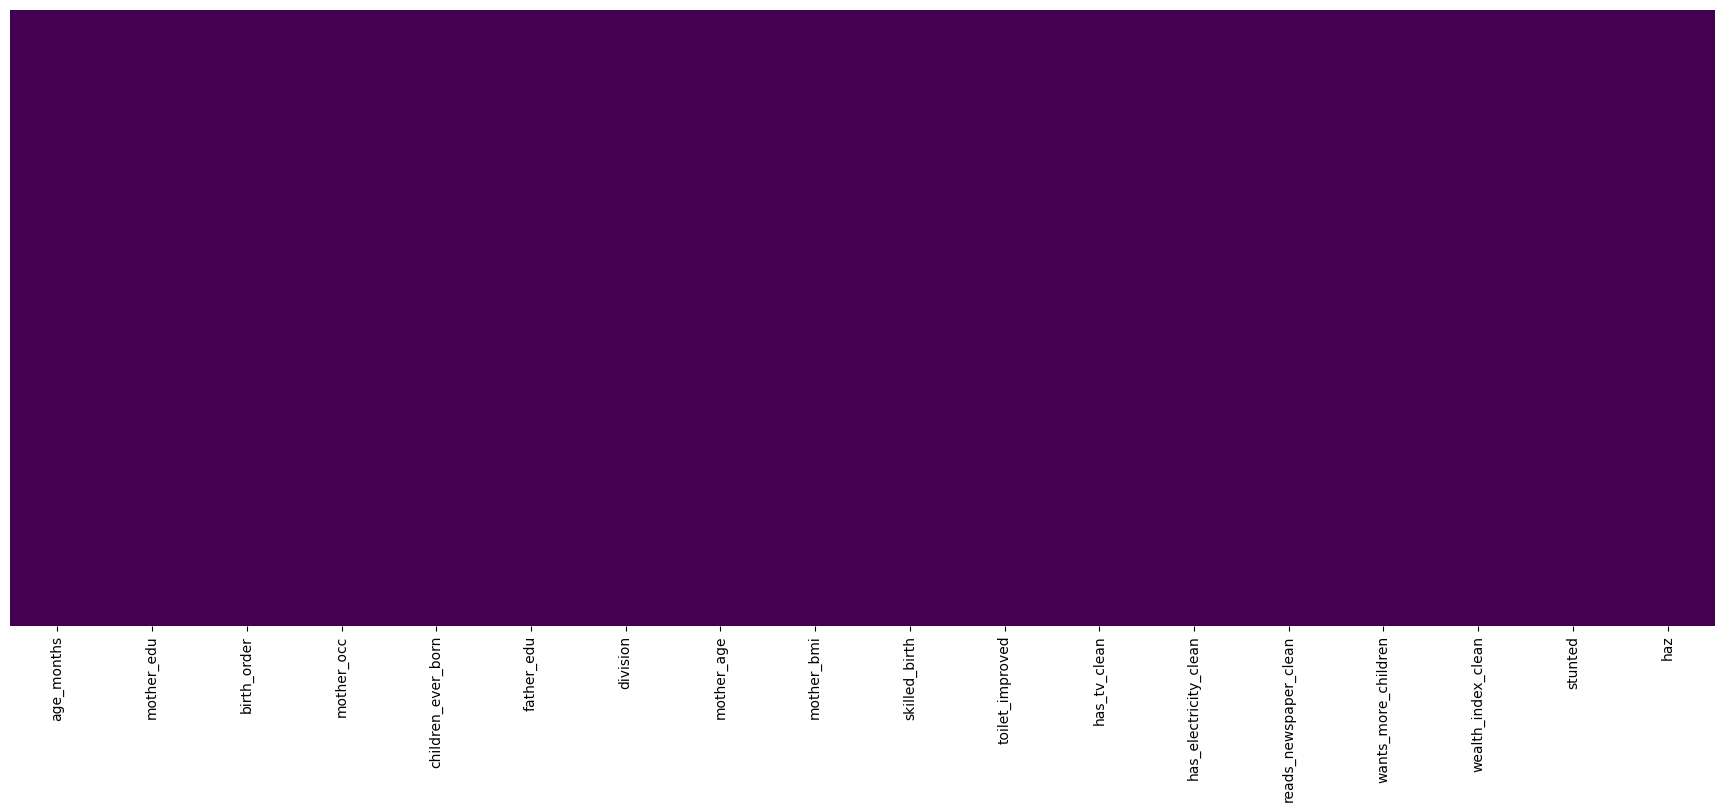

In [9]:
plt.figure(figsize=(22, 8))
sns.heatmap(
  df.sample(200).isnull(),  # sample rows
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.show()

# Bar chart

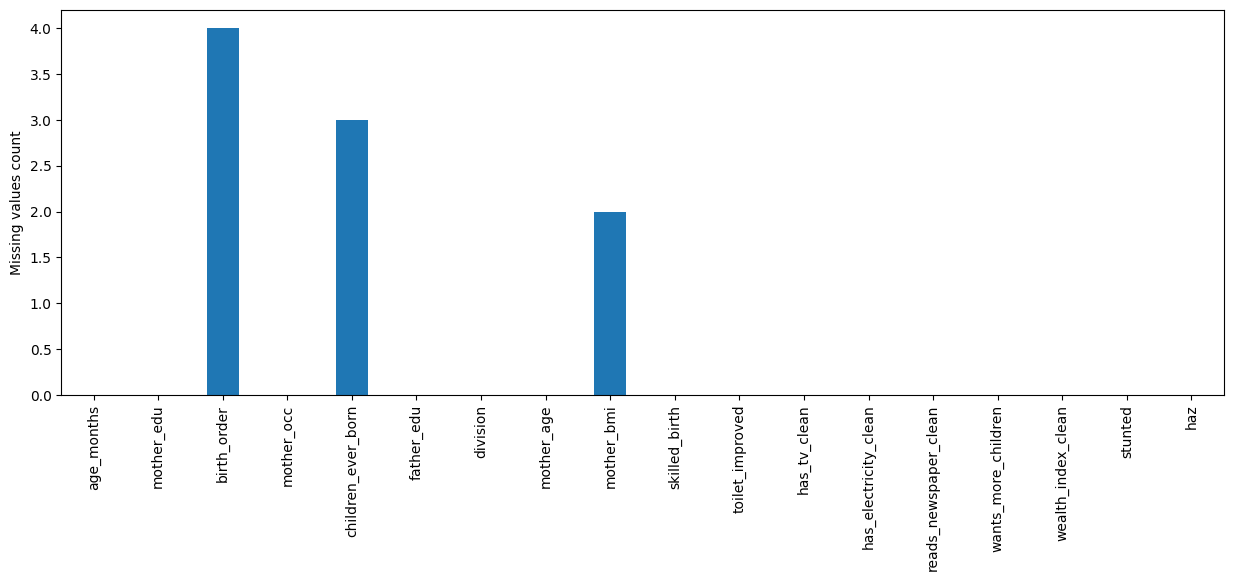

In [10]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.ylabel("Missing values count")
plt.show() # bar chart


In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                 Variable  Missing_Percent
2             birth_order           0.1016
4      children_ever_born           0.0762
8              mother_bmi           0.0508
0              age_months           0.0000
1              mother_edu           0.0000
3              mother_occ           0.0000
5              father_edu           0.0000
6                division           0.0000
7              mother_age           0.0000
9           skilled_birth           0.0000
10        toilet_improved           0.0000
11           has_tv_clean           0.0000
12  has_electricity_clean           0.0000
13  reads_newspaper_clean           0.0000
14    wants_more_children           0.0000
15     wealth_index_clean           0.0000
16                stunted           0.0000
17                    haz           0.0000


In [12]:
df.shape

(3937, 18)

In [13]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['age_months', 'mother_edu', 'birth_order', 'mother_occ',
       'children_ever_born', 'father_edu', 'division', 'mother_age',
       'mother_bmi', 'skilled_birth', 'toilet_improved', 'has_tv_clean',
       'has_electricity_clean', 'reads_newspaper_clean', 'wants_more_children',
       'wealth_index_clean', 'stunted', 'haz'],
      dtype='object')

In [14]:
numeric_vars = [
   'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]


In [15]:
all_df_cols = df.columns.tolist()

# Filter numeric_vars to only include columns that are still in df
current_numeric_vars = [col for col in numeric_vars if col in all_df_cols]

# Categorical = everything else
categorical_vars = list(set(all_df_cols) - set(current_numeric_vars))

print("Numeric variables:")
for col in current_numeric_vars:
    print(f"  - {col}")

print("\nCategorical variables:")
for col in categorical_vars:
    print(f"  - {col}")

Numeric variables:
  - age_months
  - children_ever_born
  - mother_age
  - birth_order
  - mother_bmi

Categorical variables:
  - has_electricity_clean
  - father_edu
  - skilled_birth
  - mother_edu
  - wants_more_children
  - division
  - has_tv_clean
  - reads_newspaper_clean
  - stunted
  - haz
  - wealth_index_clean
  - mother_occ
  - toilet_improved


# Normality check

In [16]:


# Numeric (continuous) variables from our dataset
numeric_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

normality_results = []

for col in numeric_vars:
    data = df[col].dropna()

    # Skip very small samples
    if len(data) < 10:
        continue

    skewness = data.skew()

    # Shapiro test (sample if dataset is large)
    stat, p_value = shapiro(data.sample(500) if len(data) > 500 else data)

    normality_results.append({
        "Variable": col,
        "Skewness": round(skewness, 3),
        "Shapiro_p_value": round(p_value, 4),
        "Distribution": "Normal" if p_value > 0.05 else "Non-normal"
    })

# Create normality table
normality_table = pd.DataFrame(normality_results)

normality_table


,Variable,Skewness,Shapiro_p_value,Distribution
0,age_months,-0.046,0.0,Non-normal
1,children_ever_born,1.286,0.0,Non-normal
2,mother_age,0.503,0.0,Non-normal
3,birth_order,1.274,0.0,Non-normal
4,mother_bmi,0.645,0.0,Non-normal


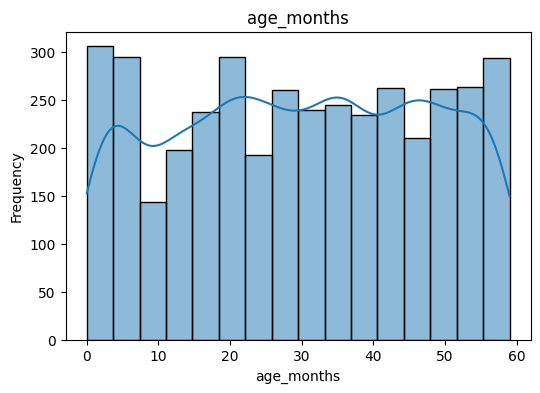

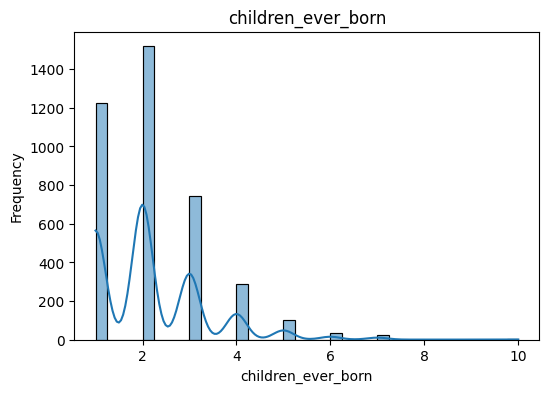

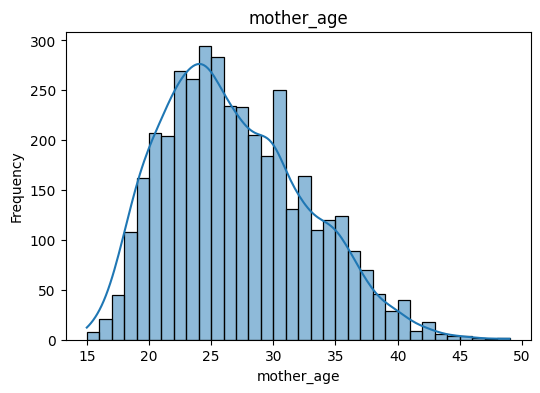

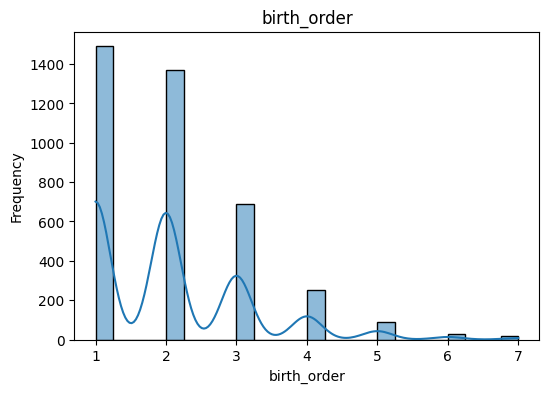

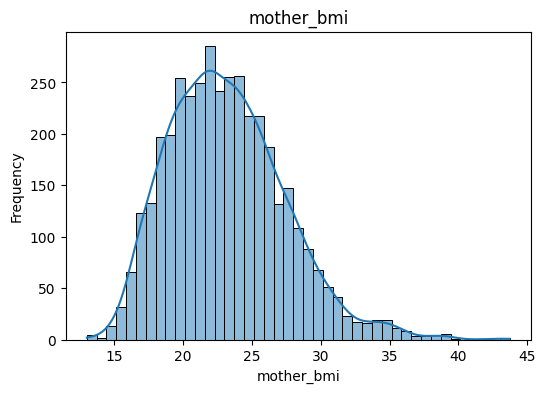

In [17]:


# List of numeric variables (non-normal)
numeric_cols = [
      'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

# Plot each variable individually
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)   # pass only one column at a time
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Median filling

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_months,3937.0,29.924054,17.490272,0.00,15.00,30.00,45.000,59.00
mother_edu,3937.0,1.832868,0.798249,0.00,1.00,2.00,2.000,3.00
birth_order,3933.0,2.042207,1.109814,1.00,1.00,2.00,3.000,7.00
mother_occ,3937.0,0.242570,0.428692,0.00,0.00,0.00,0.000,1.00
children_ever_born,3934.0,2.164209,1.135149,1.00,1.00,2.00,3.000,10.00
father_edu,3937.0,1.588011,0.964006,0.00,1.00,2.00,2.000,3.00
division,3937.0,3.549149,1.926412,1.00,2.00,3.00,5.000,7.00
mother_age,3937.0,26.740665,5.729555,15.00,22.00,26.00,30.000,49.00
mother_bmi,3935.0,23.163972,4.207058,13.00,20.04,22.81,25.725,43.71
skilled_birth,3937.0,0.404369,0.490832,0.00,0.00,0.00,1.000,1.00


In [19]:
# Verify all supposedly-categorical variables are already integer-coded
categorical_vars_expected = [
    'mother_edu', 'mother_occ', 'father_edu', 'division',
    'skilled_birth', 'toilet_improved', 'has_tv_clean',
    'has_electricity_clean', 'reads_newspaper_clean',
    'wants_more_children', 'wealth_index_clean'
]

print("Column dtypes:")
for col in categorical_vars_expected:
    if col in df.columns:
        print(f"  {col}: {df[col].dtype}")
    else:
        print(f"  {col}: NOT IN DATAFRAME")

Column dtypes:
  mother_edu: int64
  mother_occ: int64
  father_edu: int64
  division: int64
  skilled_birth: int64
  toilet_improved: int64
  has_tv_clean: int64
  has_electricity_clean: int64
  reads_newspaper_clean: int64
  wants_more_children: int64
  wealth_index_clean: int64


### **Univariate Analysis (1st numerical 2nd categorical)**
# histplot and countplot to understand  the distribution




### Correlation heatmap for Numerical variable.

#boxplot to identify the outlier

In [20]:
def iqr_outliers(df, columns):
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lb) | (df[col] > ub)]

        outlier_info[col] = {
            "lower_bound": lb,
            "upper_bound": ub,
            "num_outliers": outliers.shape[0]
        }

    return outlier_info


In [21]:
columns_to_check = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

outlier_results = iqr_outliers(df, columns_to_check)


In [22]:
for col, stats in outlier_results.items():
    print(f"\nColumn: {col}")
    print("Lower bound:", stats["lower_bound"])
    print("Upper bound:", stats["upper_bound"])
    print("Number of outliers:", stats["num_outliers"])



Column: age_months
Lower bound: -30.0
Upper bound: 90.0
Number of outliers: 0

Column: children_ever_born
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 23

Column: mother_age
Lower bound: 10.0
Upper bound: 42.0
Number of outliers: 19

Column: birth_order
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 16

Column: mother_bmi
Lower bound: 11.512499999999996
Upper bound: 34.252500000000005
Number of outliers: 58


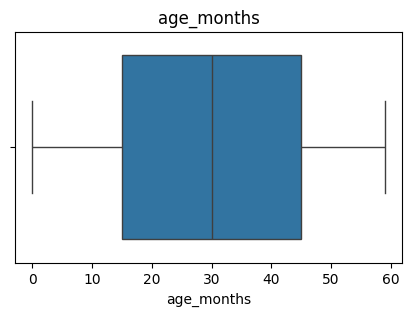

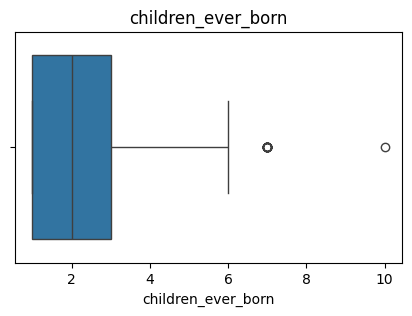

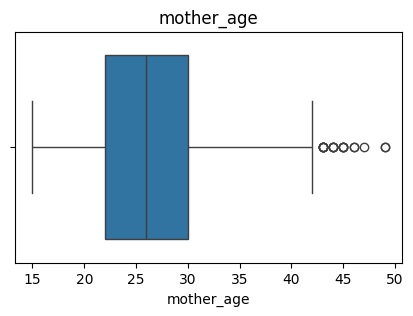

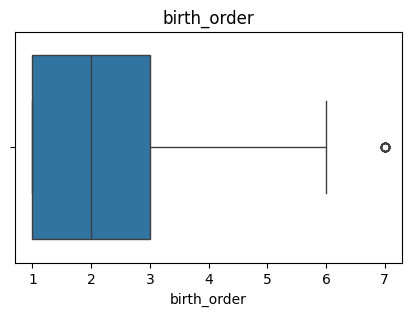

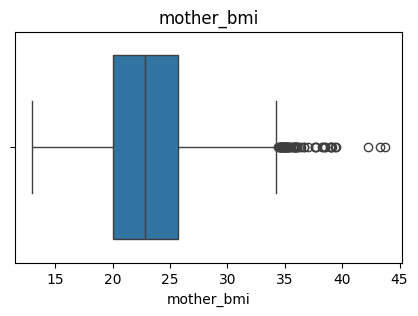

In [23]:
for col in columns_to_check:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


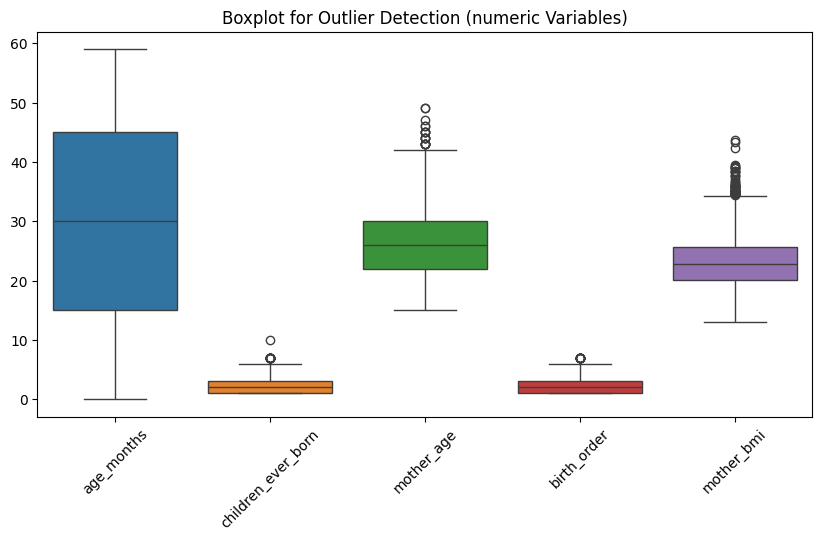

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection (numeric Variables)")
plt.show()



# whisker use to handle outlier

### Scaling numerical variables

# class imbalance checking

In [25]:
# Class counts
stunted_counts = df['stunted'].value_counts()

# Class percentages
stunted_percent = df['stunted'].value_counts(normalize=True) * 100

print("Class Counts:")
print(stunted_counts)

print("\nClass Percentages (%):")
print(stunted_percent.round(2))


Class Counts:
stunted
0    2994
1     943
Name: count, dtype: int64

Class Percentages (%):
stunted
0    76.05
1    23.95
Name: proportion, dtype: float64


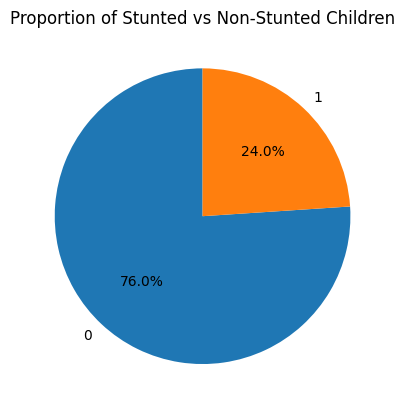

In [26]:
df['stunted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Proportion of Stunted vs Non-Stunted Children')
plt.show()



# Train Test Split (80% train, 20% test)

In [27]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Target
y = df["stunted"].astype(int)

# Drop non-predictor columns
# (note: sample_weight, wt, child_line aren't in the current dataset but
#  we keep the errors='ignore' defensively in case of schema changes)
drop_cols = ["stunted", "haz", "sample_weight", "wt", "child_line"]
X = df.drop(columns=drop_cols, errors="ignore")

# Split — stratified to preserve the ~23.95% stunted rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Save master split indices for downstream feature-selection blocks
train_idx = X_train.index
test_idx = X_test.index

# Sanity checks
print("Final feature count:", X.shape[1])
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("haz in X?", "haz" in X.columns)
print("stunted in X?", "stunted" in X.columns)
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(4))
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(4))
print()
print("Missing values remaining in X_train:", X_train.isnull().sum().sum())
print("Missing values remaining in X_test:", X_test.isnull().sum().sum())

Final feature count: 16
Train shape: (3149, 16)
Test shape: (788, 16)

haz in X? False
stunted in X? False

Train class balance:
stunted
0    0.7606
1    0.2394
Name: proportion, dtype: float64

Test class balance:
stunted
0    0.7602
1    0.2398
Name: proportion, dtype: float64

Missing values remaining in X_train: 9
Missing values remaining in X_test: 0


In [28]:
# -----------------------------------------------------------
# Point 2: Median imputation (replaces MICE)
# -----------------------------------------------------------
# Rationale: Only 9 missing values (<0.05% of data) across 3 variables.
# All 5 non-normal variables are right-skewed (Shapiro-Wilk p < 0.05),
# so median is the appropriate statistic over mean.
# Medians are learned from TRAINING data only and applied to both
# train and test — preserving the test set as a simulation of
# unseen data.
# -----------------------------------------------------------

from sklearn.impute import SimpleImputer

# Columns that have missing values (same as non_normal_vars intersection)
cols_to_impute = ['age_months', 'children_ever_born', 'mother_age',
                  'birth_order', 'mother_bmi']

# Fit the imputer on X_train only
median_imputer = SimpleImputer(strategy='median')
median_imputer.fit(X_train[cols_to_impute])

# Transform both X_train and X_test using the train-learned medians
X_train[cols_to_impute] = median_imputer.transform(X_train[cols_to_impute])
X_test[cols_to_impute]  = median_imputer.transform(X_test[cols_to_impute])

# Verification
print("Medians learned from X_train:")
for col, median in zip(cols_to_impute, median_imputer.statistics_):
    print(f"  {col}: {median}")
print()
print("Missing values in X_train after imputation:", X_train.isnull().sum().sum())
print("Missing values in X_test after imputation:",  X_test.isnull().sum().sum())

Medians learned from X_train:
  age_months: 30.0
  children_ever_born: 2.0
  mother_age: 26.0
  birth_order: 2.0
  mother_bmi: 22.83

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [29]:
# -----------------------------------------------------------
# Point 3: IQR winsorization (replaces pre-split winsorization)
# -----------------------------------------------------------
# Rationale: Non-normal numeric variables have right-skewed tails
# (children_ever_born skew=1.29, birth_order skew=1.27, etc.).
# Extreme values can destabilize distance-based and linear models.
# Winsorization clips values at Q1-1.5*IQR and Q3+1.5*IQR.
# IQR bounds are learned from TRAINING data only and applied to both
# train and test — preserving the test set as unseen data.
# -----------------------------------------------------------

import numpy as np

cols_to_winsorize = ['age_months', 'children_ever_born', 'mother_age',
                     'birth_order', 'mother_bmi']

# Dictionary to store the bounds learned from training data
winsor_bounds = {}

for col in cols_to_winsorize:
    # Compute IQR bounds on TRAINING data only
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    winsor_bounds[col] = {'lower': lower, 'upper': upper}

    # Apply those same train-learned bounds to both train and test
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col]  = X_test[col].clip(lower=lower, upper=upper)

# Verification
print("Winsorization bounds learned from X_train:")
for col, bounds in winsor_bounds.items():
    n_clipped_train = ((X_train[col] == bounds['lower']) | (X_train[col] == bounds['upper'])).sum()
    n_clipped_test  = ((X_test[col]  == bounds['lower']) | (X_test[col]  == bounds['upper'])).sum()
    print(f"  {col}: [{bounds['lower']:.2f}, {bounds['upper']:.2f}]  "
          f"(clipped: train={n_clipped_train}, test={n_clipped_test})")

Winsorization bounds learned from X_train:
  age_months: [-30.00, 90.00]  (clipped: train=0, test=0)
  children_ever_born: [-2.00, 6.00]  (clipped: train=50, test=5)
  mother_age: [8.50, 44.50]  (clipped: train=9, test=0)
  birth_order: [-2.00, 6.00]  (clipped: train=40, test=4)
  mother_bmi: [11.47, 34.35]  (clipped: train=46, test=12)


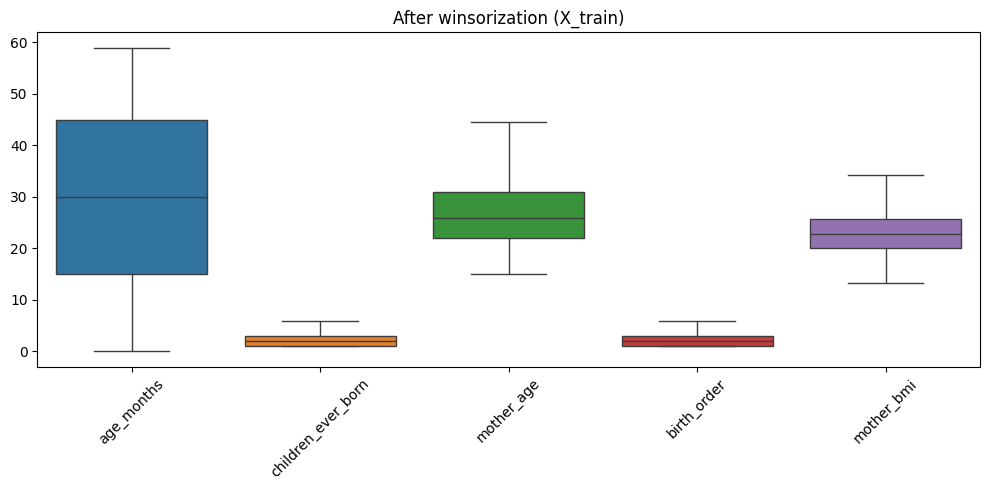

In [30]:
# -----------------------------------------------------------
# Verification viz: Post-winsorization boxplots (X_train)
# -----------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['age_months', 'children_ever_born', 'mother_age',
                'birth_order', 'mother_bmi']

plt.figure(figsize=(10, 5))
sns.boxplot(data=X_train[cols_to_plot])
plt.xticks(rotation=45)
plt.title("After winsorization (X_train)")
plt.tight_layout()
plt.show()

In [31]:
# -----------------------------------------------------------
# Scaling: RobustScaler on 5 numeric variables
# -----------------------------------------------------------
# Rationale: Numeric variables are non-normal (Shapiro-Wilk p<0.05)
# with some skew. RobustScaler uses median and IQR, which are
# less affected by the remaining distribution shape than mean/std
# would be. Distance-based (KNN, SVM) and linear (LogReg) models
# benefit from scaling; tree-based models are unaffected but also
# not harmed. Fit on X_train only, applied to both sets.
# Categorical DHS-coded integers are left unscaled to preserve
# their interpretation as category labels.
# -----------------------------------------------------------

from sklearn.preprocessing import RobustScaler

cols_to_scale = ['age_months', 'children_ever_born', 'mother_age',
                 'birth_order', 'mother_bmi']

scaler = RobustScaler()

# Fit on training data only
scaler.fit(X_train[cols_to_scale])

# Transform both train and test using the same train-learned parameters
X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

# Verification
print("RobustScaler parameters learned from X_train:")
print(f"  Medians (center): {dict(zip(cols_to_scale, scaler.center_.round(3)))}")
print(f"  IQRs    (scale):  {dict(zip(cols_to_scale, scaler.scale_.round(3)))}")
print()
print("X_train scaled columns — summary statistics:")
print(X_train[cols_to_scale].describe().round(3).loc[['mean', 'std', 'min', 'max']])
print()
print("Categorical columns unchanged (spot check — first 3):")
cat_sample = ['division', 'wealth_index_clean', 'mother_edu']
print(X_train[cat_sample].describe().round(3).loc[['mean', 'min', 'max']])

RobustScaler parameters learned from X_train:
  Medians (center): {'age_months': np.float64(30.0), 'children_ever_born': np.float64(2.0), 'mother_age': np.float64(26.0), 'birth_order': np.float64(2.0), 'mother_bmi': np.float64(22.83)}
  IQRs    (scale):  {'age_months': np.float64(30.0), 'children_ever_born': np.float64(2.0), 'mother_age': np.float64(9.0), 'birth_order': np.float64(2.0), 'mother_bmi': np.float64(5.72)}

X_train scaled columns — summary statistics:
      age_months  children_ever_born  mother_age  birth_order  mother_bmi
mean      -0.007               0.081       0.088         0.02       0.059
std        0.586               0.559       0.641         0.55       0.721
min       -1.000              -0.500      -1.222        -0.50      -1.668
max        0.967               2.000       2.056         2.00       2.014

Categorical columns unchanged (spot check — first 3):
      division  wealth_index_clean  mother_edu
mean     3.535               2.939       1.837
min      1.00

# feature list

In [32]:
print(f"X_train shape: {X_train.shape}\n")
for i, feat in enumerate(X_train.columns, start=1):
    print(f"{i:>2}. {feat}")

X_train shape: (3149, 16)

 1. age_months
 2. mother_edu
 3. birth_order
 4. mother_occ
 5. children_ever_born
 6. father_edu
 7. division
 8. mother_age
 9. mother_bmi
10. skilled_birth
11. toilet_improved
12. has_tv_clean
13. has_electricity_clean
14. reads_newspaper_clean
15. wants_more_children
16. wealth_index_clean


# 1. Filter Method: SelectKBest with Mutual Information

This selects top features based on mutual information (measures dependency between features and target).
It's fast and doesn't overfit, but ignores feature interactions.

In [33]:
# ======================================================================
# Feature Selection — Method 1 of 6: Mutual Information (Filter)
# ======================================================================
# Purpose: rank all 16 features by mutual information (MI) with the
# target. The ranking feeds into the aggregation step after all six
# methods run.
#
# Pipeline discipline (what changed vs. the original cell):
#   - Uses the already-preprocessed X_train (imputed, winsorized, scaled).
#     No re-slicing, no re-imputation, no one-hot encoding.
#   - fillna(0) removed — data is already clean post-split.
#   - SMOTE removed — happens once, after aggregation, before model fit.
#   - MI fit on REAL (non-resampled) training data so importance
#     reflects genuine feature–target relationships.
#
# Note on discrete_features:
#   mutual_info_classif treats features as continuous by default, which
#   is wrong for our 11 int-coded DHS categoricals. We pass an explicit
#   boolean mask so MI is estimated correctly per feature type.
# ======================================================================

from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Discrete-feature mask: True for categorical, False for the 5 numerics.
numeric_vars = ['age_months', 'children_ever_born', 'mother_age',
                'birth_order', 'mother_bmi']
discrete_mask = [col not in numeric_vars for col in X_train.columns]

# Compute MI on clean training data only.
mi_scores = mutual_info_classif(
    X_train, y_train,
    discrete_features=discrete_mask,
    random_state=42
)

# Attach feature names and sort descending.
mi_ranking = pd.Series(mi_scores, index=X_train.columns) \
               .sort_values(ascending=False)

print("Mutual Information scores (all features, ranked):")
print(mi_ranking.round(4).to_string())

# Top-15 selection stored for the rank-aggregation step.
mi_selected = mi_ranking.head(15).index.tolist()
print(f"\nmi_selected (top 15): {mi_selected}")

Mutual Information scores (all features, ranked):
mother_bmi               0.0196
wealth_index_clean       0.0175
mother_edu               0.0167
birth_order              0.0128
father_edu               0.0126
children_ever_born       0.0093
age_months               0.0052
division                 0.0050
has_tv_clean             0.0044
toilet_improved          0.0039
reads_newspaper_clean    0.0036
skilled_birth            0.0022
has_electricity_clean    0.0005
wants_more_children      0.0001
mother_occ               0.0000
mother_age               0.0000

mi_selected (top 15): ['mother_bmi', 'wealth_index_clean', 'mother_edu', 'birth_order', 'father_edu', 'children_ever_born', 'age_months', 'division', 'has_tv_clean', 'toilet_improved', 'reads_newspaper_clean', 'skilled_birth', 'has_electricity_clean', 'wants_more_children', 'mother_occ']


In [34]:
print(f"Excluded from top-15: {set(X_train.columns) - set(mi_selected)}")

Excluded from top-15: {'mother_age'}


# 2. Wrapper Method: Recursive Feature Elimination (RFE) with LogisticRegression
This recursively removes least important features using a model (here, LogisticRegression for multiclass). More accurate but slower.

In [35]:
# ======================================================================
# Feature Selection — Method 2 of 6: RFE (Wrapper, Logistic Regression)
# ======================================================================
# Pipeline discipline:
#   - Uses the already-preprocessed X_train. No re-slicing.
#   - SMOTE removed — happens once, after aggregation, before model fit.
#   - class_weight='balanced' on the base estimator because SMOTE hasn't
#     been applied yet — stops the LR coefficients from being dominated
#     by the 76% non-stunted majority.
#   - n_features_to_select=1 → RFE eliminates features one at a time down
#     to the last one, producing a complete 1-to-16 ranking needed for
#     the rank-aggregation step.
# ======================================================================

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

estimator = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

selector = RFE(estimator, n_features_to_select=1, step=1)
selector.fit(X_train, y_train)

# ranking_[i] = 1 → best; higher numbers eliminated earlier.
rfe_ranking = pd.Series(selector.ranking_, index=X_train.columns) \
                .sort_values(ascending=True)

print("RFE ranking (1 = best, 16 = eliminated first):")
print(rfe_ranking.to_string())

rfe_selected = rfe_ranking.head(15).index.tolist()
print(f"\nrfe_selected (top 15): {rfe_selected}")
print(f"Excluded: {set(X_train.columns) - set(rfe_selected)}")

RFE ranking (1 = best, 16 = eliminated first):
reads_newspaper_clean     1
mother_edu                2
mother_bmi                3
children_ever_born        4
wants_more_children       5
toilet_improved           6
age_months                7
skilled_birth             8
wealth_index_clean        9
mother_age               10
mother_occ               11
birth_order              12
division                 13
father_edu               14
has_electricity_clean    15
has_tv_clean             16

rfe_selected (top 15): ['reads_newspaper_clean', 'mother_edu', 'mother_bmi', 'children_ever_born', 'wants_more_children', 'toilet_improved', 'age_months', 'skilled_birth', 'wealth_index_clean', 'mother_age', 'mother_occ', 'birth_order', 'division', 'father_edu', 'has_electricity_clean']
Excluded: {'has_tv_clean'}


In [36]:
print("mi_ranking type:", type(mi_ranking).__name__, "| length:", len(mi_ranking))
print("rfe_ranking type:", type(rfe_ranking).__name__, "| length:", len(rfe_ranking))

mi_ranking type: Series | length: 16
rfe_ranking type: Series | length: 16


# 3.Boruta Algorithm

In [37]:
!pip install boruta


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.7 MB/s eta 0:00:00


In [38]:
# ======================================================================
# Feature Selection — Method 3 of 6: Boruta (Wrapper, Random Forest)
# ======================================================================
# Pipeline discipline:
#   - Uses already-preprocessed X_train directly. No re-slicing.
#   - No fillna(0). No SMOTE. No re-encoding.
#   - class_weight='balanced' on the base RF compensates for 76/24
#     imbalance (SMOTE is deferred until after aggregation).
#   - random_state=42 everywhere (locked-in project convention).
#
# How Boruta differs from MI and RFE:
#   Boruta creates "shadow features" — permuted copies of each real
#   feature with identical distribution but zero true relationship to
#   the target. A feature is "confirmed" only if its importance beats
#   the best shadow repeatedly across iterations. It's a statistical
#   test on top of RF importance, not just a ranking — it answers "is
#   this feature provably better than noise?"
#
# Compatibility note:
#   BorutaPy 0.4.3 uses np.int / np.float / np.bool which were removed
#   in numpy 2.0. We restore the aliases before importing BorutaPy.
# ======================================================================

import numpy as np

# Restore deprecated numpy aliases BEFORE importing BorutaPy.
if not hasattr(np, 'int'):   np.int = int
if not hasattr(np, 'float'): np.float = float
if not hasattr(np, 'bool'):  np.bool = bool

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Shallow, balanced RF — Boruta's recommended configuration.
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',   # Boruta overrides the RF's n_estimators
    max_iter=100,
    random_state=42,
    verbose=0
)

# Boruta requires numpy arrays.
boruta.fit(X_train.values, y_train.values)

# ranking_: 1 = confirmed; higher = rejected earlier in iterations.
boruta_ranking = pd.Series(boruta.ranking_, index=X_train.columns) \
                   .sort_values(ascending=True)

print("Boruta ranking (1 = confirmed, higher = rejected earlier):")
print(boruta_ranking.to_string())

print(f"\nConfirmed: {list(X_train.columns[boruta.support_])}")
print(f"Tentative: {list(X_train.columns[boruta.support_weak_])}")

boruta_selected = boruta_ranking.head(15).index.tolist()
print(f"\nboruta_selected (top 15): {boruta_selected}")
print(f"Excluded: {set(X_train.columns) - set(boruta_selected)}")

Boruta ranking (1 = confirmed, higher = rejected earlier):
age_months                1
mother_edu                1
father_edu                1
children_ever_born        1
wealth_index_clean        1
mother_bmi                1
mother_age                2
birth_order               3
division                  4
has_tv_clean              5
toilet_improved           5
reads_newspaper_clean     7
skilled_birth             8
wants_more_children       9
mother_occ               10
has_electricity_clean    11

Confirmed: ['age_months', 'mother_edu', 'children_ever_born', 'father_edu', 'mother_bmi', 'wealth_index_clean']
Tentative: []

boruta_selected (top 15): ['age_months', 'mother_edu', 'father_edu', 'children_ever_born', 'wealth_index_clean', 'mother_bmi', 'mother_age', 'birth_order', 'division', 'has_tv_clean', 'toilet_improved', 'reads_newspaper_clean', 'skilled_birth', 'wants_more_children', 'mother_occ']
Excluded: {'has_electricity_clean'}


In [39]:
print("mi_ranking:     ", len(mi_ranking))
print("rfe_ranking:    ", len(rfe_ranking))
print("boruta_ranking: ", len(boruta_ranking))

mi_ranking:      16
rfe_ranking:     16
boruta_ranking:  16


# 4. L1 Logistic

In [40]:
# ======================================================================
# Feature Selection — Method 4 of 6: L1-Logistic Regression (Embedded)
# ======================================================================
# Replaces the original Lasso snippet. Justification for the swap:
#   Lasso (sklearn.linear_model.Lasso) is linear regression with L1
#   penalty — designed for CONTINUOUS targets. Applying it to a binary
#   0/1 target technically runs, but it fits a regression line through
#   probabilities clipped at 0 and 1, which is not what we want.
#   LogisticRegression with penalty='l1' is the correct classification
#   analogue: same L1 sparsity property, but fit via log-likelihood
#   appropriate for binary outcomes.
#
# Pipeline discipline:
#   - Uses already-preprocessed X_train. No re-slicing, no fillna(0).
#   - SMOTE removed — one SMOTE call after aggregation.
#   - class_weight='balanced' because SMOTE is deferred; without it,
#     L1 would push the minority-class signals to zero first.
#
# Why coefficient magnitudes are comparable:
#   RobustScaler has already put the 5 numeric features on a comparable
#   scale (centered at median, scaled by IQR). The 11 DHS categoricals
#   are int-coded with small ranges (mostly 0-7). This means |coef_| is
#   a legitimate importance signal across features.
# ======================================================================

from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

l1_logistic = LogisticRegression(
    penalty='l1',
    solver='liblinear',     # liblinear supports L1
    C=1.0,                  # moderate regularization; lower C = stronger penalty
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

l1_logistic.fit(X_train, y_train)

# coef_ has shape (1, n_features) for binary classification.
l1_ranking = pd.Series(
    np.abs(l1_logistic.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

print("L1-Logistic ranking (absolute coefficient magnitudes):")
print(l1_ranking.round(4).to_string())

# Count how many features survived L1 sparsity.
nonzero = (l1_ranking > 0).sum()
print(f"\nNon-zero coefficients: {nonzero} / {len(l1_ranking)}")

l1_selected = l1_ranking.head(15).index.tolist()
print(f"\nl1_selected (top 15): {l1_selected}")
print(f"Excluded: {set(X_train.columns) - set(l1_selected)}")

L1-Logistic ranking (absolute coefficient magnitudes):
children_ever_born       0.3833
reads_newspaper_clean    0.3539
age_months               0.3323
mother_bmi               0.2481
mother_edu               0.2442
wants_more_children      0.2247
skilled_birth            0.1784
wealth_index_clean       0.1628
toilet_improved          0.1541
mother_age               0.1371
mother_occ               0.0856
birth_order              0.0690
division                 0.0681
father_edu               0.0527
has_tv_clean             0.0000
has_electricity_clean    0.0000

Non-zero coefficients: 14 / 16

l1_selected (top 15): ['children_ever_born', 'reads_newspaper_clean', 'age_months', 'mother_bmi', 'mother_edu', 'wants_more_children', 'skilled_birth', 'wealth_index_clean', 'toilet_improved', 'mother_age', 'mother_occ', 'birth_order', 'division', 'father_edu', 'has_tv_clean']
Excluded: {'has_electricity_clean'}


In [41]:
print("mi_ranking:     ", len(mi_ranking))
print("rfe_ranking:    ", len(rfe_ranking))
print("boruta_ranking: ", len(boruta_ranking))
print("l1_ranking:     ", len(l1_ranking))

mi_ranking:      16
rfe_ranking:     16
boruta_ranking:  16
l1_ranking:      16


# 5.Grey Wolf Optimizer (GWO)  Feature Selection

Works well for complex datasets,
 Handles non-linear relationships,
 Avoids local minima,
 Good balance between exploration & exploitation,

In [42]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [43]:
# ======================================================================
# Feature Selection — Method 5 of 6: Grey Wolf Optimizer (Metaheuristic)
# ======================================================================
# Pipeline discipline:
#   - Uses already-preprocessed X_train directly. No re-slicing, no
#     fillna(0), no in-cell SMOTE.
#   - CatBoost uses class_weights=[1, 3.18] ≈ inverse class frequency
#     to compensate for the 76/24 imbalance.
#
# THE CORE FIX (Point 7 of the 10-point plan):
#   The original fitness function scored candidate subsets on X_test —
#   i.e. GWO was optimizing feature selection against the held-out
#   test set. Every iteration leaked test information into the choice
#   of features, and the reported "Best Score = 0.7335" was inflated.
#
#   The fix: inside fitness_function, we carve a train_sub/val_sub
#   split out of X_train only. Candidates are fit on train_sub and
#   scored on val_sub. X_test is not visible inside this scope — the
#   function signature doesn't even receive it.
#
# Scoring choice: F1 on the minority (stunted) class.
#   Accuracy collapses to 0.76 for the trivial "predict 0" classifier
#   on a 76/24 split. F1 rewards actually detecting stunted children.
#
# Ranking extraction:
#   GWO returns a binary mask. For rank aggregation we need an ordinal
#   ranking across all 16 features. We track how often each feature
#   appears in the top-3 wolves (alpha/beta/delta) across iterations;
#   higher selection frequency → better rank.
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

# Reproducibility — GWO is stochastic.
np.random.seed(42)

# ----------------------------------------------------------------------
# Internal validation split: this is the anti-leakage fix.
# fit_sub / val_sub live ENTIRELY inside X_train. X_test is untouched.
# ----------------------------------------------------------------------
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)
X_fit_np  = X_fit.values
X_val_np  = X_val.values
y_fit_np  = y_fit.values
y_val_np  = y_val.values

n_features = X_train.shape[1]

# Class weights — inverse frequency, hard-coded for reproducibility.
# y_train is ~76/24, so the minority weight is 76/24 ≈ 3.18.
pos_weight = (y_fit == 0).sum() / (y_fit == 1).sum()
cat_weights = [1.0, float(pos_weight)]

# ----------------------------------------------------------------------
# Fitness function. Signature does NOT receive X_test/y_test. Leakage
# is structurally impossible in this scope.
# ----------------------------------------------------------------------
def fitness_function(subset):
    n_selected = int(np.sum(subset))
    if n_selected == 0:
        return 0.0

    Xf = X_fit_np[:, subset == 1]
    Xv = X_val_np[:, subset == 1]

    model = CatBoostClassifier(
        iterations=50,
        depth=4,
        verbose=0,
        random_state=42,
        class_weights=cat_weights
    )
    model.fit(Xf, y_fit_np)
    y_pred = model.predict(Xv).astype(int).ravel()

    f1 = f1_score(y_val_np, y_pred, pos_label=1)

    # Small parsimony penalty: prefers smaller subsets when F1 is tied.
    parsimony = 0.01 * (n_selected / n_features)
    return f1 - parsimony

# ----------------------------------------------------------------------
# GWO parameters.
# ----------------------------------------------------------------------
n_wolves = 10
max_iter = 20
a_max, a_min = 2.0, 0.0

# Initialize population — at least one feature per wolf.
population = np.random.randint(0, 2, (n_wolves, n_features))
for i in range(n_wolves):
    if population[i].sum() == 0:
        population[i, np.random.randint(n_features)] = 1

alpha_pos = np.zeros(n_features, dtype=int)
beta_pos  = np.zeros(n_features, dtype=int)
delta_pos = np.zeros(n_features, dtype=int)
alpha_score = beta_score = delta_score = -np.inf

# Track how often each feature appears in top-3 wolves — basis for ranking.
selection_frequency = np.zeros(n_features)

# ----------------------------------------------------------------------
# GWO main loop.
# ----------------------------------------------------------------------
for it in range(max_iter):
    a = a_max - (a_max - a_min) * (it / max_iter)

    # Evaluate fitness and update alpha/beta/delta.
    for i in range(n_wolves):
        f = fitness_function(population[i])
        if f > alpha_score:
            delta_score, delta_pos = beta_score,  beta_pos.copy()
            beta_score,  beta_pos  = alpha_score, alpha_pos.copy()
            alpha_score, alpha_pos = f, population[i].copy()
        elif f > beta_score:
            delta_score, delta_pos = beta_score, beta_pos.copy()
            beta_score,  beta_pos  = f, population[i].copy()
        elif f > delta_score:
            delta_score, delta_pos = f, population[i].copy()

    # Accumulate top-3 selection frequency for ranking.
    selection_frequency += alpha_pos + beta_pos + delta_pos

    # Position update.
    for i in range(n_wolves):
        for j in range(n_features):
            r1, r2 = np.random.rand(), np.random.rand()
            A1, C1 = 2 * a * r1 - a, 2 * r2
            X1 = alpha_pos[j] - A1 * abs(C1 * alpha_pos[j] - population[i][j])

            r1, r2 = np.random.rand(), np.random.rand()
            A2, C2 = 2 * a * r1 - a, 2 * r2
            X2 = beta_pos[j]  - A2 * abs(C2 * beta_pos[j]  - population[i][j])

            r1, r2 = np.random.rand(), np.random.rand()
            A3, C3 = 2 * a * r1 - a, 2 * r2
            X3 = delta_pos[j] - A3 * abs(C3 * delta_pos[j] - population[i][j])

            new_pos = (X1 + X2 + X3) / 3.0
            sigmoid = 1.0 / (1.0 + np.exp(-10 * (new_pos - 0.5)))
            population[i][j] = 1 if sigmoid > 0.5 else 0

        # Safety: never let a wolf degenerate to all-zeros.
        if population[i].sum() == 0:
            population[i, np.random.randint(n_features)] = 1

    print(f"Iter {it+1:>2}: alpha F1 = {alpha_score:.4f} "
          f"| n_features in alpha = {int(alpha_pos.sum())}")

# ----------------------------------------------------------------------
# Results.
# ----------------------------------------------------------------------
gwo_ranking = pd.Series(selection_frequency, index=X_train.columns) \
                .sort_values(ascending=False)

print("\nGWO ranking (selection frequency across top-3 wolves × iterations):")
print(gwo_ranking.astype(int).to_string())

gwo_selected = gwo_ranking.head(15).index.tolist()
print(f"\nBest alpha F1 (on internal validation): {alpha_score:.4f}")
print(f"gwo_selected (top 15): {gwo_selected}")
print(f"Excluded: {set(X_train.columns) - set(gwo_selected)}")

Iter  1: alpha F1 = 0.4235 | n_features in alpha = 12
Iter  2: alpha F1 = 0.4235 | n_features in alpha = 12
Iter  3: alpha F1 = 0.4285 | n_features in alpha = 11
Iter  4: alpha F1 = 0.4285 | n_features in alpha = 11
Iter  5: alpha F1 = 0.4430 | n_features in alpha = 10
Iter  6: alpha F1 = 0.4430 | n_features in alpha = 10
Iter  7: alpha F1 = 0.4430 | n_features in alpha = 10
Iter  8: alpha F1 = 0.4430 | n_features in alpha = 10
Iter  9: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 10: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 11: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 12: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 13: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 14: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 15: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 16: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 17: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 18: alpha F1 = 0.4430 | n_features in alpha = 10
Iter 19: alpha F1 = 0.4430 |

In [44]:
print("mi_ranking:     ", len(mi_ranking))
print("rfe_ranking:    ", len(rfe_ranking))
print("boruta_ranking: ", len(boruta_ranking))
print("l1_ranking:     ", len(l1_ranking))
print("gwo_ranking:    ", len(gwo_ranking))

mi_ranking:      16
rfe_ranking:     16
boruta_ranking:  16
l1_ranking:      16
gwo_ranking:     16


# 6. snake optimization

In [45]:
# ======================================================================
# Feature Selection — Method 6 of 6: Snake Optimizer (Metaheuristic)
# ======================================================================
# Pipeline discipline — identical to GWO cell for methodological parity:
#   - Uses already-preprocessed X_train. No re-slicing, no fillna(0),
#     no in-cell SMOTE.
#   - CatBoost fitness evaluator with identical config to GWO — this
#     makes GWO vs Snake results directly comparable (any ranking
#     difference reflects the optimizer, not the base learner).
#
# THE CORE FIX (Point 8 of the 10-point plan):
#   Original fitness function scored subsets on X_test, same leakage
#   pattern as the old GWO cell. Every iteration's "Best Fitness"
#   was contaminated test-set accuracy.
#
#   Fix: carve X_fit/X_val out of X_train only. Candidates fit on
#   X_fit, scored on X_val. X_test never enters this scope.
#
# Scoring: F1 on the minority (stunted) class (not accuracy).
#
# Ranking extraction:
#   Snake returns a binary mask from the best snake only. We accumulate
#   selection frequency of the best snake across iterations — features
#   that stay in the optimum repeatedly get higher ranks.
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

np.random.seed(42)

# ----------------------------------------------------------------------
# Internal validation split — the anti-leakage fix.
# Same seed/proportions as GWO for comparability.
# ----------------------------------------------------------------------
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)
X_fit_np = X_fit.values
X_val_np = X_val.values
y_fit_np = y_fit.values
y_val_np = y_val.values

n_features = X_train.shape[1]

pos_weight = (y_fit == 0).sum() / (y_fit == 1).sum()
cat_weights = [1.0, float(pos_weight)]

# ----------------------------------------------------------------------
# Fitness function — signature receives no test data.
# ----------------------------------------------------------------------
def fitness_function(subset):
    n_selected = int(np.sum(subset))
    if n_selected == 0:
        return 0.0

    Xf = X_fit_np[:, subset == 1]
    Xv = X_val_np[:, subset == 1]

    model = CatBoostClassifier(
        iterations=50,
        depth=4,
        verbose=0,
        random_state=42,
        class_weights=cat_weights
    )
    model.fit(Xf, y_fit_np)
    y_pred = model.predict(Xv).astype(int).ravel()

    f1 = f1_score(y_val_np, y_pred, pos_label=1)
    parsimony = 0.01 * (n_selected / n_features)
    return f1 - parsimony

# ----------------------------------------------------------------------
# Snake Optimizer parameters.
# ----------------------------------------------------------------------
n_snakes = 20
max_iter = 50
c1 = 1.0   # probability of imitating the best snake
c2 = 0.5   # probability of random mutation if not imitating

# Initialize population — ensure no snake is all-zeros.
population = np.random.randint(0, 2, (n_snakes, n_features))
for i in range(n_snakes):
    if population[i].sum() == 0:
        population[i, np.random.randint(n_features)] = 1

best_snake = np.zeros(n_features, dtype=int)
best_fitness = -np.inf

# Track selection frequency across iterations for ranking.
selection_frequency = np.zeros(n_features)

# ----------------------------------------------------------------------
# Snake Optimizer main loop.
# ----------------------------------------------------------------------
for it in range(max_iter):
    fitness_values = np.array([fitness_function(population[i])
                               for i in range(n_snakes)])

    max_idx = np.argmax(fitness_values)
    if fitness_values[max_idx] > best_fitness:
        best_fitness = fitness_values[max_idx]
        best_snake = population[max_idx].copy()

    # Accumulate selection frequency from the current best.
    selection_frequency += best_snake

    # Update population.
    for i in range(n_snakes):
        for j in range(n_features):
            r1 = np.random.rand()
            r2 = np.random.rand()
            if r1 < c1:
                population[i][j] = best_snake[j]
            elif r2 < c2:
                population[i][j] = np.random.randint(0, 2)

        if population[i].sum() == 0:
            population[i, np.random.randint(n_features)] = 1

    print(f"Iter {it+1:>2}: best F1 = {best_fitness:.4f} "
          f"| n_features in best = {int(best_snake.sum())}")

# ----------------------------------------------------------------------
# Results.
# ----------------------------------------------------------------------
snake_ranking = pd.Series(selection_frequency, index=X_train.columns) \
                  .sort_values(ascending=False)

print("\nSnake Optimizer ranking (selection frequency of best snake across iterations):")
print(snake_ranking.astype(int).to_string())

snake_selected = snake_ranking.head(15).index.tolist()
print(f"\nBest F1 (on internal validation): {best_fitness:.4f}")
print(f"snake_selected (top 15): {snake_selected}")
print(f"Excluded: {set(X_train.columns) - set(snake_selected)}")

Iter  1: best F1 = 0.4235 | n_features in best = 12
Iter  2: best F1 = 0.4235 | n_features in best = 12
Iter  3: best F1 = 0.4235 | n_features in best = 12
Iter  4: best F1 = 0.4235 | n_features in best = 12
Iter  5: best F1 = 0.4235 | n_features in best = 12
Iter  6: best F1 = 0.4235 | n_features in best = 12
Iter  7: best F1 = 0.4235 | n_features in best = 12
Iter  8: best F1 = 0.4235 | n_features in best = 12
Iter  9: best F1 = 0.4235 | n_features in best = 12
Iter 10: best F1 = 0.4235 | n_features in best = 12
Iter 11: best F1 = 0.4235 | n_features in best = 12
Iter 12: best F1 = 0.4235 | n_features in best = 12
Iter 13: best F1 = 0.4235 | n_features in best = 12
Iter 14: best F1 = 0.4235 | n_features in best = 12
Iter 15: best F1 = 0.4235 | n_features in best = 12
Iter 16: best F1 = 0.4235 | n_features in best = 12
Iter 17: best F1 = 0.4235 | n_features in best = 12
Iter 18: best F1 = 0.4235 | n_features in best = 12
Iter 19: best F1 = 0.4235 | n_features in best = 12
Iter 20: bes

In [46]:
rankings = {
    'mi_ranking':     mi_ranking,
    'rfe_ranking':    rfe_ranking,
    'boruta_ranking': boruta_ranking,
    'l1_ranking':     l1_ranking,
    'gwo_ranking':    gwo_ranking,
    'snake_ranking':  snake_ranking,
}
for name, r in rankings.items():
    print(f"{name:18s} type={type(r).__name__:7s} length={len(r)}")

mi_ranking         type=Series  length=16
rfe_ranking        type=Series  length=16
boruta_ranking     type=Series  length=16
l1_ranking         type=Series  length=16
gwo_ranking        type=Series  length=16
snake_ranking      type=Series  length=16


# Result of feature selection methods

In [47]:
# ======================================================================
# Feature Selection — Step 7 of 7: Rank Aggregation (Point 10)
# ======================================================================
# Combines the six independent rankings (MI, RFE, Boruta, L1-Logistic,
# GWO, Snake) into a consensus ranking via AVERAGE RANK, then selects
# the top 15 features for modelling.
#
# Method:
#   Each method's output is converted to an integer rank (1 = best in
#   that method) with ties averaged. The six ranks per feature are
#   averaged. Lowest average rank wins.
#
# Direction of each ranking (for reference):
#   mi_ranking      : higher MI score   = better
#   rfe_ranking     : lower rank number = better  (invert for scoring)
#   boruta_ranking  : lower rank number = better  (invert for scoring)
#   l1_ranking      : higher |coef|     = better
#   gwo_ranking     : higher frequency  = better
#   snake_ranking   : higher frequency  = better
#
# Why aggregate:
#   Each method captures a different view of importance — information-
#   theoretic, linear wrapper, statistical test against noise, sparse
#   linear, and two metaheuristic subset searches. No single method is
#   authoritative. Averaging ranks reflects consensus and makes the
#   final feature set methodologically defensible.
# ======================================================================

import pandas as pd
import numpy as np

feature_names = X_train.columns.tolist()

# Normalize each ranking so that higher = better before ranking.
scores = pd.DataFrame(index=feature_names)
scores['MI']     = mi_ranking
scores['RFE']    = -rfe_ranking      # invert
scores['Boruta'] = -boruta_ranking   # invert
scores['L1']     = l1_ranking
scores['GWO']    = gwo_ranking
scores['Snake']  = snake_ranking

# Convert each method's score to an integer rank (1 = best), ties averaged.
rank_df = scores.rank(ascending=False, method='average')
rank_df['Average_Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Average_Rank')

print("Per-method ranks + average rank (1 = best):")
print(rank_df.round(2).to_string())

# ----------------------------------------------------------------------
# Final selection: top 15 by lowest average rank.
# ----------------------------------------------------------------------
final_features = rank_df.head(15).index.tolist()

X_train_selected = X_train[final_features].copy()
X_test_selected  = X_test[final_features].copy()

print("\nFinal selected features (top 15 by average rank):")
for i, feat in enumerate(final_features, start=1):
    avg = rank_df.loc[feat, 'Average_Rank']
    print(f"  {i:>2}. {feat:25s} (avg rank = {avg:.2f})")

excluded = set(feature_names) - set(final_features)
print(f"\nExcluded from final feature set: {excluded}")
print(f"\nX_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected  shape: {X_test_selected.shape}")

Per-method ranks + average rank (1 = best):
                         MI   RFE  Boruta    L1   GWO  Snake  Average_Rank
mother_edu              3.0   2.0     3.5   5.0   2.5    6.5          3.75
mother_bmi              1.0   3.0     3.5   4.0   8.0    6.5          4.33
age_months              7.0   7.0     3.5   3.0   2.5    6.5          4.92
children_ever_born      6.0   4.0     3.5   1.0  10.0   14.5          6.50
reads_newspaper_clean  11.0   1.0    12.0   2.0   9.0   14.5          8.25
wants_more_children    14.0   5.0    14.0   6.0   5.5    6.5          8.50
wealth_index_clean      2.0   9.0     3.5   8.0  16.0   14.5          8.83
skilled_birth          12.0   8.0    13.0   7.0   7.0    6.5          8.92
birth_order             4.0  12.0     8.0  12.0  12.0    6.5          9.08
toilet_improved        10.0   6.0    10.5   9.0  13.0    6.5          9.17
mother_age             16.0  10.0     7.0  10.0   5.5    6.5          9.17
father_edu              5.0  14.0     3.5  14.0  14.0   

In [48]:
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected  shape:", X_test_selected.shape)
print("y_train shape:         ", y_train.shape)
print("y_test shape:          ", y_test.shape)
print("y_train class counts:\n", y_train.value_counts())

X_train_selected shape: (3149, 15)
X_test_selected  shape: (788, 15)
y_train shape:          (3149,)
y_test shape:           (788,)
y_train class counts:
 stunted
0    2395
1     754
Name: count, dtype: int64


# Smote, only valid one

In [49]:
# ======================================================================
# SMOTE — THE ONLY SMOTE CALL IN THE NOTEBOOK
# ======================================================================
# Resolves Points 4, 5, and 9 of the 10-point plan.
#
# Position (Point 4): after feature selection + aggregation, before
# model fit. This is the correct order — feature importance was
# computed on real (non-resampled) data, so the rankings reflect
# genuine feature–target relationships. Resampling only happens now,
# on the final selected feature set, to balance training data for the
# models.
#
# Consolidation (Point 9): all in-cell SMOTE calls in the six FS cells
# were removed during Phase 1. This is the single consolidated SMOTE
# step. If the notebook is re-run from the top, this is the only cell
# that will resample anything.
#
# Scope discipline:
#   - Operates ONLY on (X_train_selected, y_train).
#   - X_test_selected and y_test are NEVER resampled. The test set must
#     remain at its natural 76/24 imbalance so evaluation reflects the
#     true target distribution.
#
# What SMOTE does here:
#   Synthesizes new minority-class (stunted) training examples by
#   interpolating between existing minority points and their k-nearest
#   minority neighbors. Result: training set becomes 50/50 balanced.
#   This helps models learn the minority class without being
#   overwhelmed by the majority.
# ======================================================================

from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_selected, y_train
)

# fit_resample returns numpy arrays if input was ndarray, or DataFrame/
# Series if input was DataFrame/Series. With pandas input, column names
# are preserved — but we convert defensively for consistency downstream.
X_train_resampled = pd.DataFrame(
    X_train_resampled, columns=X_train_selected.columns
)
y_train_resampled = pd.Series(y_train_resampled, name='stunted')

print("BEFORE SMOTE:")
print(f"  X_train_selected shape: {X_train_selected.shape}")
print(f"  y_train class counts:\n{y_train.value_counts().to_string()}")

print("\nAFTER SMOTE:")
print(f"  X_train_resampled shape: {X_train_resampled.shape}")
print(f"  y_train_resampled class counts:\n{y_train_resampled.value_counts().to_string()}")

print("\nTest set (UNCHANGED — SMOTE not applied):")
print(f"  X_test_selected shape: {X_test_selected.shape}")
print(f"  y_test class counts:\n{y_test.value_counts().to_string()}")

print("\n" + "=" * 60)
print("Variables to use downstream in modelling:")
print("  TRAIN: X_train_resampled, y_train_resampled  (balanced 50/50)")
print("  TEST:  X_test_selected,    y_test            (original 76/24)")
print("=" * 60)

BEFORE SMOTE:
  X_train_selected shape: (3149, 15)
  y_train class counts:
stunted
0    2395
1     754

AFTER SMOTE:
  X_train_resampled shape: (4790, 15)
  y_train_resampled class counts:
stunted
0    2395
1    2395

Test set (UNCHANGED — SMOTE not applied):
  X_test_selected shape: (788, 15)
  y_test class counts:
stunted
0    599
1    189

Variables to use downstream in modelling:
  TRAIN: X_train_resampled, y_train_resampled  (balanced 50/50)
  TEST:  X_test_selected,    y_test            (original 76/24)


In [50]:
print(f"Train rows: {len(y_train)} | Test rows: {len(y_test)} | Total: {len(y_train) + len(y_test)}")
print(f"Original dataset rows: {len(df)}")

Train rows: 3149 | Test rows: 788 | Total: 3937
Original dataset rows: 3937


Before SMOTE (Training Set Only):
stunted
0    2395
1     754

Percentage before SMOTE:
stunted
0    76.06
1    23.94

After SMOTE (Training Set Only):
stunted
0    2395
1    2395

Percentage after SMOTE:
stunted
0    50.0
1    50.0


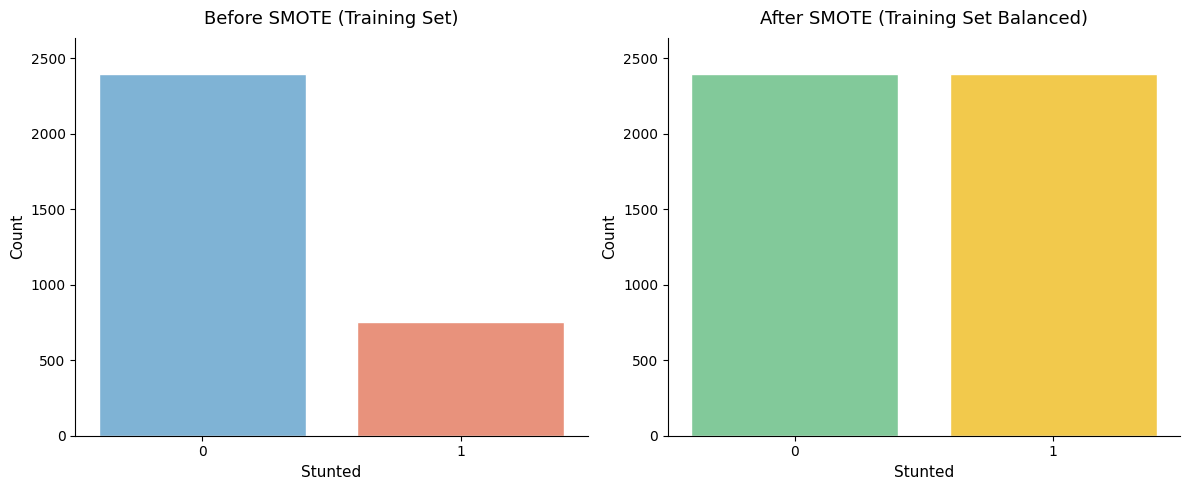

In [51]:
# ======================================================================
# Visualization: Class Balance Before and After SMOTE
# ======================================================================
# Two-panel comparison of the training set class distribution before
# and after the single SMOTE call. Test set excluded by design —
# it remains at its natural ~76/24 distribution for honest evaluation.
# ======================================================================

import matplotlib.pyplot as plt

# ----- Counts -----
before_counts = y_train.value_counts().sort_index()
after_counts  = y_train_resampled.value_counts().sort_index()

before_pct = y_train.value_counts(normalize=True).sort_index() * 100
after_pct  = y_train_resampled.value_counts(normalize=True).sort_index() * 100

# ----- Text summary -----
print("Before SMOTE (Training Set Only):")
print(before_counts.to_string())
print("\nPercentage before SMOTE:")
print(before_pct.round(2).to_string())

print("\n" + "=" * 50)
print("After SMOTE (Training Set Only):")
print(after_counts.to_string())
print("\nPercentage after SMOTE:")
print(after_pct.round(2).to_string())

# ----- Two-panel plot -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left panel — Before SMOTE
ax1.bar(before_counts.index.astype(str),
        before_counts.values,
        color=['#7FB3D5', '#E8927C'],     # soft blue / soft coral
        edgecolor='white', linewidth=1)
ax1.set_title('Before SMOTE (Training Set)', fontsize=13, pad=10)
ax1.set_xlabel('Stunted', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right panel — After SMOTE
ax2.bar(after_counts.index.astype(str),
        after_counts.values,
        color=['#82C99A', '#F2C94C'],     # soft green / soft amber
        edgecolor='white', linewidth=1)
ax2.set_title('After SMOTE (Training Set Balanced)', fontsize=13, pad=10)
ax2.set_xlabel('Stunted', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Shared y-limit so the two panels are visually comparable
ymax = max(before_counts.max(), after_counts.max()) * 1.1
ax1.set_ylim(0, ymax)
ax2.set_ylim(0, ymax)

plt.tight_layout()
plt.show()

# Now heading to model fit step.

In [52]:


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

In [53]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
)
import numpy as np
import pandas as pd

# ========== TRAIN & EVALUATE ALL MODELS ==========
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"TRAINING: {name}")
    print(f"{'='*50}")

    try:
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test_selected)

        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test_selected)[:, 1]
        else:
            y_prob = model.decision_function(X_test_selected)

        train_acc = accuracy_score(y_train_resampled, model.predict(X_train_resampled)) * 100
        test_acc = accuracy_score(y_test, y_pred) * 100

        print("Train Accuracy (%):", round(train_acc, 2))
        print("Test Accuracy (%):", round(test_acc, 2))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print("TN {}".format(cm[0, 0]))
        print("FP {}".format(cm[0, 1]))
        print("FN {}".format(cm[1, 0]))
        print("TP {}".format(cm[1, 1]))

        print("Accuracy rate {:.2f}".format((cm[0, 0] + cm[1, 1]) / np.sum(cm) * 100))
        print("Misclassification rate {:.2f}".format((cm[0, 1] + cm[1, 0]) / np.sum(cm) * 100))

        # Metrics
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall:", recall_score(y_test, y_pred))
        print("F1-score:", f1_score(y_test, y_pred))
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))

        # Store results
        results.append({
            'Model': name,
            'Train_Acc': train_acc,
            'Test_Acc': test_acc,
            'F1': f1_score(y_test, y_pred),
            'ROC_AUC': roc_auc_score(y_test, y_prob),
            'Overfit_Gap': (train_acc - test_acc) / 100
        })

        print("-" * 50)

    except Exception as e:
        print(f"❌ ERROR in {name}: {str(e)}")
        results.append({'Model': name, 'Error': str(e)})

# ========== SUMMARY TABLE ==========
results_df = pd.DataFrame(results).sort_values('Test_Acc', ascending=False)
print("\n🏆 FINAL RANKING (Test Accuracy):")
print("=" * 60)
print(results_df.round(3).to_string(index=False))


TRAINING: Logistic Regression
Train Accuracy (%): 65.05
Test Accuracy (%): 61.68
TN 380
FP 219
FN 83
TP 106
Accuracy rate 61.68
Misclassification rate 38.32
Precision: 0.3261538461538461
Recall: 0.5608465608465608
F1-score: 0.41245136186770426
ROC-AUC: 0.643038220667603
--------------------------------------------------

TRAINING: K-Nearest Neighbors
Train Accuracy (%): 84.07
Test Accuracy (%): 57.99
TN 355
FP 244
FN 87
TP 102
Accuracy rate 57.99
Misclassification rate 42.01
Precision: 0.2947976878612717
Recall: 0.5396825396825397
F1-score: 0.3813084112149533
ROC-AUC: 0.5843425108867513
--------------------------------------------------

TRAINING: Decision Tree
Train Accuracy (%): 68.18
Test Accuracy (%): 61.93
TN 394
FP 205
FN 95
TP 94
Accuracy rate 61.93
Misclassification rate 38.07
Precision: 0.31438127090301005
Recall: 0.4973544973544973
F1-score: 0.38524590163934425
ROC-AUC: 0.6118398388849142
--------------------------------------------------

TRAINING: Random Forest
Train Accur

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Train Accuracy (%): 72.51
Test Accuracy (%): 66.12
TN 433
FP 166
FN 101
TP 88
Accuracy rate 66.12
Misclassification rate 33.88
Precision: 0.3464566929133858
Recall: 0.4656084656084656
F1-score: 0.3972911963882618
ROC-AUC: 0.6377825476322971
--------------------------------------------------

TRAINING: SVM
Train Accuracy (%): 69.29
Test Accuracy (%): 63.83
TN 404
FP 195
FN 90
TP 99
Accuracy rate 63.83
Misclassification rate 36.17
Precision: 0.336734693877551
Recall: 0.5238095238095238
F1-score: 0.40993788819875776
ROC-AUC: 0.6289053183877893
--------------------------------------------------

TRAINING: Naive Bayes
Train Accuracy (%): 64.59
Test Accuracy (%): 59.64
TN 355
FP 244
FN 74
TP 115
Accuracy rate 59.64
Misclassification rate 40.36
Precision: 0.3203342618384401
Recall: 0.6084656084656085
F1-score: 0.4197080291970803
ROC-AUC: 0.6404324668097623
--------------------------------------------------

🏆 FINAL RANKING (Test Accuracy):
              Model  Train_Acc  Test_Acc    F1  ROC_A

# KNN

In [54]:
from sklearn.metrics import accuracy_score, classification_report

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)
y_pred = knn.predict(X_test_selected)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.5799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.59      0.68       599
           1       0.29      0.54      0.38       189

    accuracy                           0.58       788
   macro avg       0.55      0.57      0.53       788
weighted avg       0.68      0.58      0.61       788



In [55]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ========== Train and Evaluate All Models ==========
results = []

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_resampled, y_train_resampled)

    train_acc = model.score(X_train_resampled, y_train_resampled) * 100
    test_acc = model.score(X_test_selected, y_test) * 100
    y_pred = model.predict(X_test_selected)

    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Predictions': y_pred
    })

    print(f"  ✓ Train Accuracy: {train_acc:.2f}%")
    print(f"  ✓ Test Accuracy:  {test_acc:.2f}%")

# ========== Create Results DataFrame ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']].to_string(index=False))

# ========== Best Model ==========
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy (%)']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")
print("=" * 80)

# ========== Detailed Evaluation for Best Model ==========
best_predictions = results_df.iloc[0]['Predictions']

print("\n" + "=" * 80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("=" * 80)

print("\n📊 CONFUSION MATRIX:")
print(confusion_matrix(y_test, best_predictions))

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_predictions))

MODEL COMPARISON

Training Logistic Regression...
  ✓ Train Accuracy: 65.05%
  ✓ Test Accuracy:  61.68%

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 84.07%
  ✓ Test Accuracy:  57.99%

Training Decision Tree...
  ✓ Train Accuracy: 68.18%
  ✓ Test Accuracy:  61.93%

Training Random Forest...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  70.69%

Training Gradient Boosting...
  ✓ Train Accuracy: 81.46%
  ✓ Test Accuracy:  69.54%

Training AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


  ✓ Train Accuracy: 72.51%
  ✓ Test Accuracy:  66.12%

Training SVM...
  ✓ Train Accuracy: 69.29%
  ✓ Test Accuracy:  63.83%

Training Naive Bayes...
  ✓ Train Accuracy: 64.59%
  ✓ Test Accuracy:  59.64%

SUMMARY TABLE
              Model  Train Accuracy (%)  Test Accuracy (%)
      Random Forest              100.00              70.69
  Gradient Boosting               81.46              69.54
           AdaBoost               72.51              66.12
                SVM               69.29              63.83
      Decision Tree               68.18              61.93
Logistic Regression               65.05              61.68
        Naive Bayes               64.59              59.64
K-Nearest Neighbors               84.07              57.99

🏆 BEST MODEL: Random Forest
   Test Accuracy: 70.69%

DETAILED EVALUATION - Random Forest

📊 CONFUSION MATRIX:
[[501  98]
 [133  56]]

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.79      0.84 

In [56]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

results = []

print("="*70)
print("COMBINED EVALUATION: METRICS + OVERFITTING CHECK")
print("="*70)

for name, model in models.items():
    print(f"Evaluating {name}...")

    # Fit once
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    train_pred = model.predict(X_train_resampled)
    test_pred = model.predict(X_test_selected)

    # Probability / score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_selected)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_selected)
    else:
        y_prob = None

    # Accuracy and overfitting gap
    train_acc = accuracy_score(y_train_resampled, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    gap = train_acc - test_acc

    # Loosened overfitting status
    if gap > 0.15:
        status = "🔴 Overfitting"
    elif gap > 0.10:
        status = "🟡 Moderate"
    else:
        status = "🟢 Good"

    results.append({
        'Model': name,
        'Train Acc (%)': round(train_acc * 100, 2),
        'Test Acc (%)': round(test_acc * 100, 2),
        'Gap': round(gap, 3),
        'Status': status,
        'Precision (%)': round(precision_score(y_test, test_pred, zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_test, test_pred, zero_division=0) * 100, 2),
        'F1 (%)':        round(f1_score(y_test, test_pred, zero_division=0) * 100, 2),
        'ROC-AUC (%)':   round(roc_auc_score(y_test, y_prob) * 100, 2) if y_prob is not None else None
    })

# Sort by F1 — that's your supervisor's target metric
results_df = pd.DataFrame(results).sort_values('F1 (%)', ascending=False)

print("\n" + "="*70)
print("📊 COMBINED PERFORMANCE + OVERFITTING TABLE")
print("="*70)
print(results_df.to_string(index=False))

overfit_count = sum(results_df['Gap'] > 0.15)
print(f"\n{overfit_count}/{len(models)} models flagged as overfitting (gap > 15%)")

COMBINED EVALUATION: METRICS + OVERFITTING CHECK
Evaluating Logistic Regression...
Evaluating K-Nearest Neighbors...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Evaluating SVM...
Evaluating Naive Bayes...

📊 COMBINED PERFORMANCE + OVERFITTING TABLE
              Model  Train Acc (%)  Test Acc (%)   Gap        Status  Precision (%)  Recall (%)  F1 (%)  ROC-AUC (%)
        Naive Bayes          64.59         59.64 0.049        🟢 Good          32.03       60.85   41.97        64.04
Logistic Regression          65.05         61.68 0.034        🟢 Good          32.62       56.08   41.25        64.30
                SVM          69.29         63.83 0.055        🟢 Good          33.67       52.38   40.99        62.89
           AdaBoost          72.51         66.12 0.064        🟢 Good          34.65       46.56   39.73        63.78
      Decision Tree          68.18         61.93 0.063        🟢 Good          31.44       49.74   38.52        61.18
K-Nearest Neighbors          84.07         57.99 0.261 🔴 Overfitting          29.48       53.97   38.13        58.43
  Gradient Boosting          81.46         69.54 0.119    🟡 Moderate          35.43       32.

# Gradient Boosting, naive bayes, logistic, AdaBoost - they are locked.

LEARNING CURVES — 8 UNTUNED BASELINE MODELS (F1, minority class)
Input            : X_train_selected (3149, 15), y_train (3149,)
CV               : 5-fold stratified, shuffle=True, random_state=42
SMOTE            : inside pipeline, per-fold only
Training sizes   : 10 points from 10% to 100%
Metric           : F1 on minority class
----------------------------------------------------------------------
  [1/8] Computing learning curve for Naive Bayes...
  [2/8] Computing learning curve for Logistic Regression...
  [3/8] Computing learning curve for SVM...
  [4/8] Computing learning curve for AdaBoost...
  [5/8] Computing learning curve for Decision Tree...
  [6/8] Computing learning curve for K-Nearest Neighbors...
  [7/8] Computing learning curve for Gradient Boosting...
  [8/8] Computing learning curve for Random Forest...


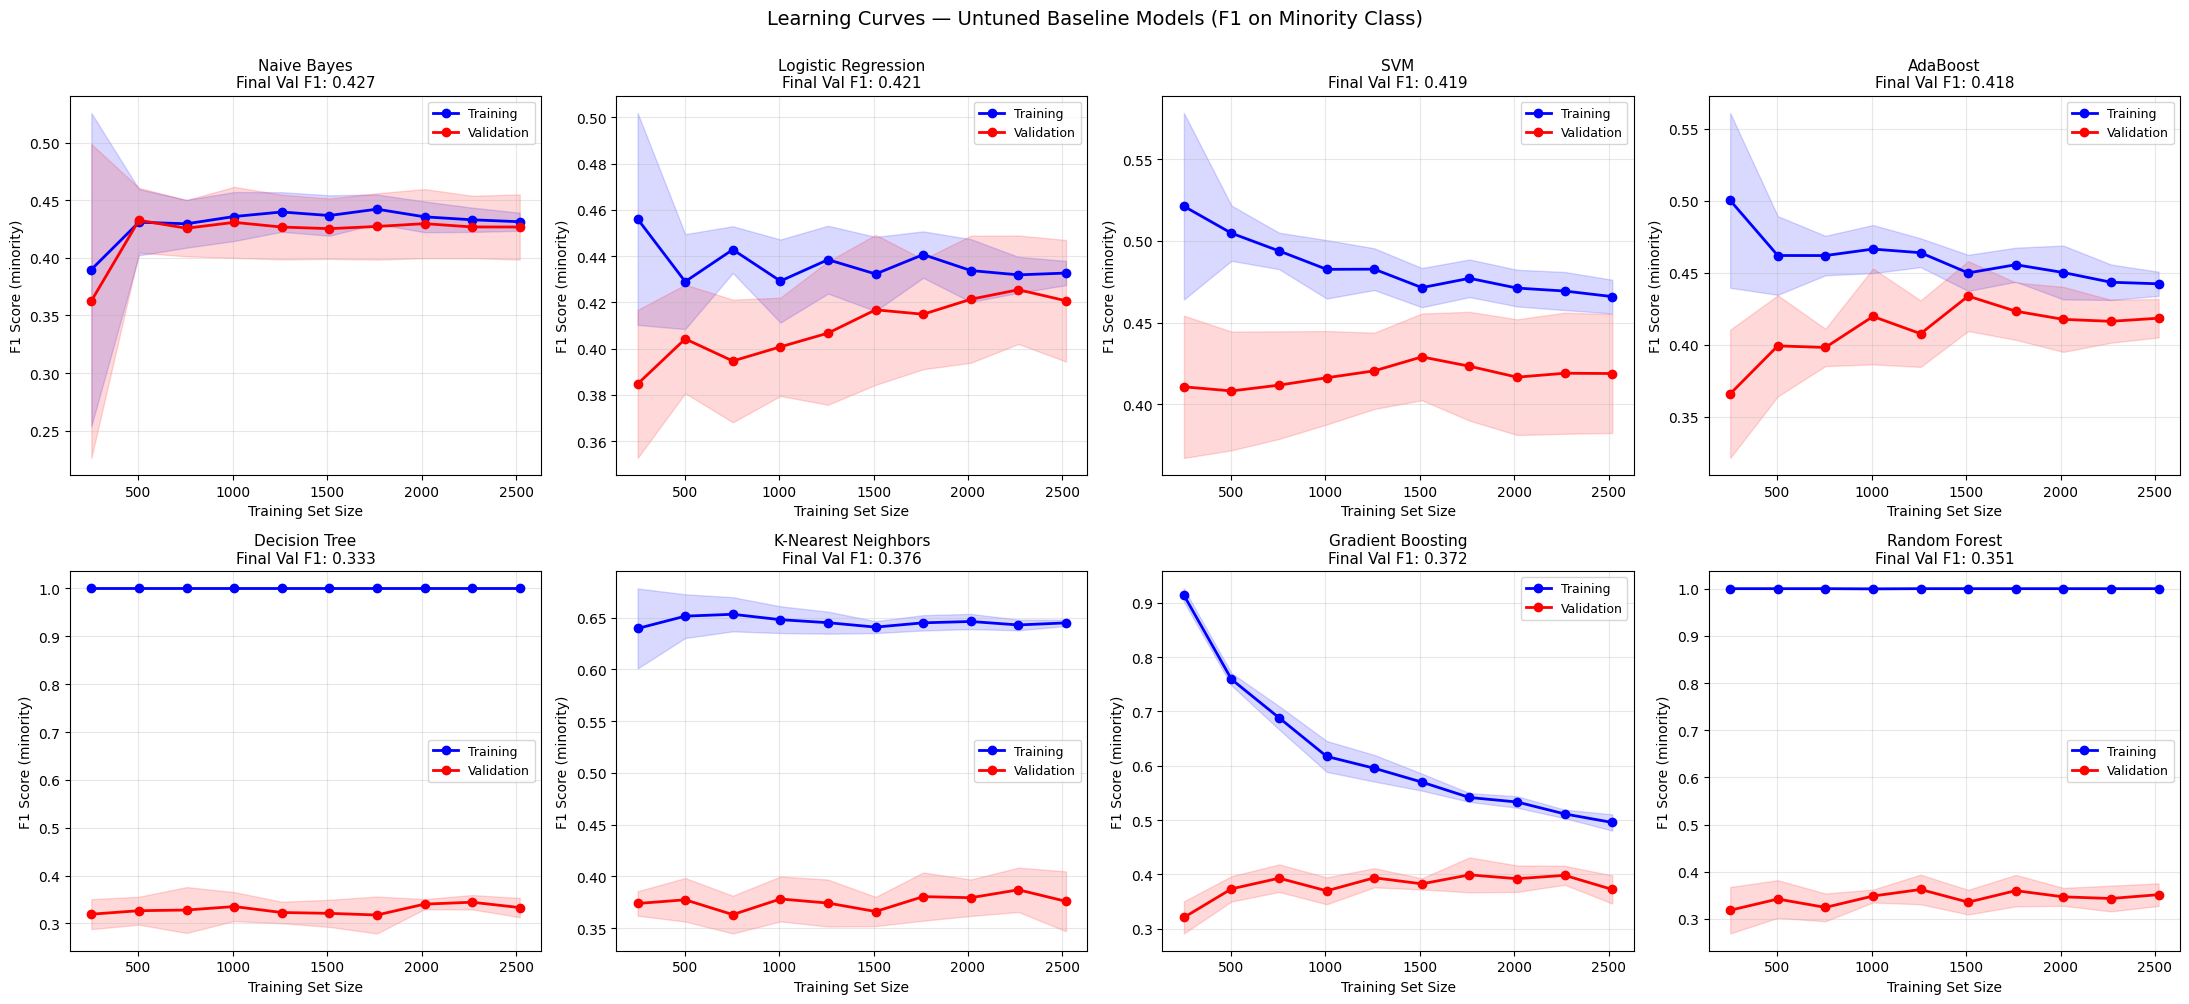


Done. Interpretation guide:
  - Large gap between train and val  → overfitting (e.g. RF, KNN)
  - Both lines low and close         → underfitting (NB, LR often)
  - Lines converging upward          → more data would help
  - Lines flat at the right edge     → model has learned all it can


In [77]:
# ======================================================================
# LEARNING CURVES — 8 UNTUNED BASELINE MODELS
# F1 on minority class, SMOTE inside pipeline (leakage-safe)
# ======================================================================
# Purpose: Visualize how each baseline model's F1 improves (or plateaus)
#   as the training set size grows. Helps diagnose overfitting,
#   underfitting, and whether more data would help each model.
#
# Matches the 8 models from the Combined Performance + Overfitting table:
#   Naive Bayes, Logistic Regression, SVM, AdaBoost, Decision Tree,
#   K-Nearest Neighbors, Gradient Boosting, Random Forest
#
# Methodology:
#   - Input: X_train_selected + y_train (PRE-SMOTE, 3149 rows)
#   - SMOTE inside ImbPipeline → applied per-fold, leakage-safe
#   - 5-fold stratified CV at each training size
#   - Metric: F1 on minority class (pos_label=1)
#   - 10 training sizes from 10% to 100% of training data
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Define the 8 baseline models (untuned, sklearn defaults) ----
# Each wrapped in an ImbPipeline with SMOTE so it runs per-fold only.
baseline_models = {
    'Naive Bayes':         GaussianNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=5000),
    'SVM':                 SVC(random_state=42, probability=True),
    'AdaBoost':            AdaBoostClassifier(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
}

# ---- Learning curve configuration ----
train_sizes_frac = np.linspace(0.1, 1.0, 10)  # 10 points from 10% to 100%
cv_splitter      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Set up the plot: 2 rows × 4 columns to hold 8 models ----
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

print("=" * 70)
print("LEARNING CURVES — 8 UNTUNED BASELINE MODELS (F1, minority class)")
print("=" * 70)
print(f"Input            : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"CV               : 5-fold stratified, shuffle=True, random_state=42")
print(f"SMOTE            : inside pipeline, per-fold only")
print(f"Training sizes   : {len(train_sizes_frac)} points from 10% to 100%")
print(f"Metric           : F1 on minority class")
print("-" * 70)

# ---- Generate learning curve for each model ----
for idx, (name, model) in enumerate(baseline_models.items()):
    print(f"  [{idx+1}/8] Computing learning curve for {name}...")

    # Wrap in ImbPipeline so SMOTE is applied per-fold, not globally
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model),
    ])

    # sklearn's learning_curve handles the progressive training + CV
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator    = pipeline,
        X            = X_train_selected,
        y            = y_train,
        train_sizes  = train_sizes_frac,
        cv           = cv_splitter,
        scoring      = 'f1',          # F1 on minority class (pos_label=1 default)
        n_jobs       = -1,
        random_state = 42,
        shuffle      = True,
    )

    # Compute mean ± std across the 5 CV folds at each training size
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # ---- Plot ----
    ax = axes[idx]
    ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training', linewidth=2)
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='blue')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='red', label='Validation', linewidth=2)
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='red')

    ax.set_title(f"{name}\nFinal Val F1: {val_mean[-1]:.3f}", fontsize=11)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1 Score (minority)")
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves — Untuned Baseline Models (F1 on Minority Class)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Done. Interpretation guide:")
print("=" * 70)
print("  - Large gap between train and val  → overfitting (e.g. RF, KNN)")
print("  - Both lines low and close         → underfitting (NB, LR often)")
print("  - Lines converging upward          → more data would help")
print("  - Lines flat at the right edge     → model has learned all it can")

# threshold tuning, Hyper parameter tuning and CV for models.

In [57]:
# ======================================================================
# THRESHOLD TUNING — Phase 2, Step 1
# ======================================================================
# Purpose: For each of the four locked models, sweep the decision
# threshold from 0.20 to 0.70 in 0.01 steps and pick the threshold
# that lands the most metrics inside the supervisor's target bands.
#
# Why this cell works AFTER the baseline cell:
#   The baseline cell above fits every model in `models` in-place.
#   This cell reuses those fitted models — no re-fit, no re-SMOTE,
#   no re-split. If you re-run this cell without having run the
#   baseline cell first, .predict_proba will raise NotFittedError,
#   which is the correct behavior (forces the right execution order).
#
# Scope: Only the four locked models. RF/KNN/DT/SVM are excluded.
#
# Note on ROC-AUC: it is computed from raw probabilities and is
# invariant to the threshold. It's included in the table because it's
# one of the five target bands, but it will be identical across all
# 51 thresholds for a given model.
#
# Tie-breaker rule (option b): If no threshold hits all 5 bands, pick
# the threshold with the highest F1 subject to accuracy >= 65% AND
# recall >= 55%. If no threshold satisfies those constraints either,
# fall back to the threshold with the highest F1 unconditionally and
# flag it as "constraints not met."
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# ---- Configuration ----
LOCKED_MODELS = ['Gradient Boosting', 'AdaBoost', 'Logistic Regression', 'Naive Bayes']

THRESHOLD_GRID = np.arange(0.20, 0.71, 0.01)  # 0.20, 0.21, ..., 0.70 (51 values)

# Target bands (inclusive on both ends)
BANDS = {
    'Accuracy':  (0.65, 0.72),
    'Precision': (0.52, 0.60),
    'Recall':    (0.55, 0.70),
    'F1':        (0.55, 0.65),
    'ROC-AUC':   (0.65, 0.72),
}

# Tiebreaker constraint (used when no threshold hits all 5 bands)
MIN_ACC_CONSTRAINT    = 0.65
MIN_RECALL_CONSTRAINT = 0.55


def count_metrics_in_bands(metrics_dict):
    """Count how many of the 5 metrics fall inside their target band."""
    count = 0
    for name, value in metrics_dict.items():
        lo, hi = BANDS[name]
        if lo <= value <= hi:
            count += 1
    return count


# ---- Sweep ----
summary_rows = []
sweep_full   = {}   # keep per-model full sweep for optional inspection

print("=" * 70)
print("THRESHOLD TUNING — sweep 0.20 to 0.70 in 0.01 steps")
print("=" * 70)

for name in LOCKED_MODELS:
    if name not in models:
        print(f"[skip] {name} not in `models` dict")
        continue

    model = models[name]

    # Probabilities for the positive (minority, stunted) class
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_selected)[:, 1]
    elif hasattr(model, "decision_function"):
        # Not expected for the four locked models, but kept for safety.
        scores = model.decision_function(X_test_selected)
        # Min-max scale to [0,1] so thresholds on the same grid make sense
        y_prob = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        print(f"[skip] {name} has neither predict_proba nor decision_function")
        continue

    # ROC-AUC is threshold-invariant — compute once per model
    roc_auc = roc_auc_score(y_test, y_prob)

    # Sweep
    rows = []
    for t in THRESHOLD_GRID:
        y_pred_t = (y_prob >= t).astype(int)
        m = {
            'Accuracy':  accuracy_score(y_test, y_pred_t),
            'Precision': precision_score(y_test, y_pred_t, zero_division=0),
            'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
            'F1':        f1_score(y_test, y_pred_t, zero_division=0),
            'ROC-AUC':   roc_auc,
        }
        rows.append({
            'Threshold':    round(float(t), 2),
            **{k: round(v, 4) for k, v in m.items()},
            'InBandCount':  count_metrics_in_bands(m),
        })
    sweep_df = pd.DataFrame(rows)
    sweep_full[name] = sweep_df

    # ---- Pick the best threshold ----
    max_in_band = sweep_df['InBandCount'].max()

    if max_in_band == 5:
        # All 5 bands satisfied — pick the row with 5, and among those
        # pick the one with the highest F1 (stable choice when multiple
        # thresholds tie at 5/5).
        candidates = sweep_df[sweep_df['InBandCount'] == 5]
        best_row = candidates.sort_values('F1', ascending=False).iloc[0]
        decision_rule = "all 5 bands met"
    else:
        # Tiebreaker: max F1 subject to Accuracy >= 0.65 AND Recall >= 0.55
        constrained = sweep_df[
            (sweep_df['Accuracy'] >= MIN_ACC_CONSTRAINT) &
            (sweep_df['Recall']   >= MIN_RECALL_CONSTRAINT)
        ]
        if len(constrained) > 0:
            best_row = constrained.sort_values('F1', ascending=False).iloc[0]
            decision_rule = f"{max_in_band}/5 bands; constrained max-F1 (acc>=65, rec>=55)"
        else:
            # Option (b) fallback: max F1 unconditionally, flag it
            best_row = sweep_df.sort_values('F1', ascending=False).iloc[0]
            decision_rule = f"{max_in_band}/5 bands; unconstrained max-F1 (constraints NOT met)"

    summary_rows.append({
        'Model':          name,
        'Best Thr':       best_row['Threshold'],
        'Accuracy (%)':   round(best_row['Accuracy']  * 100, 2),
        'Precision (%)':  round(best_row['Precision'] * 100, 2),
        'Recall (%)':     round(best_row['Recall']    * 100, 2),
        'F1 (%)':         round(best_row['F1']        * 100, 2),
        'ROC-AUC (%)':    round(best_row['ROC-AUC']   * 100, 2),
        'In-Band':        f"{int(best_row['InBandCount'])}/5",
        'Rule':           decision_rule,
    })

# ---- Summary table (threshold-tuned) ----
tuned_df = pd.DataFrame(summary_rows).sort_values('F1 (%)', ascending=False)

print("\n" + "=" * 70)
print("THRESHOLD-TUNED RESULTS (minority class)")
print("=" * 70)
print(tuned_df.to_string(index=False))

# ---- Side-by-side comparison with 0.50 baseline ----
# Rebuild the 0.50-baseline numbers for the four locked models only,
# from the same probabilities, so the comparison is apples-to-apples.
baseline_rows = []
for name in LOCKED_MODELS:
    if name not in models:
        continue
    model = models[name]
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_selected)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test_selected)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        continue
    y_pred_050 = (y_prob >= 0.50).astype(int)
    baseline_rows.append({
        'Model':         name,
        'Accuracy (%)':  round(accuracy_score(y_test, y_pred_050)         * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred_050, zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_test, y_pred_050, zero_division=0)    * 100, 2),
        'F1 (%)':        round(f1_score(y_test, y_pred_050, zero_division=0)        * 100, 2),
        'ROC-AUC (%)':   round(roc_auc_score(y_test, y_prob)              * 100, 2),
    })
baseline_df = pd.DataFrame(baseline_rows)

print("\n" + "=" * 70)
print("BASELINE @ 0.50 (for comparison, locked models only)")
print("=" * 70)
print(baseline_df.to_string(index=False))

print("\n" + "=" * 70)
print("F1 LIFT FROM THRESHOLD TUNING")
print("=" * 70)
merged = baseline_df[['Model', 'F1 (%)']].rename(columns={'F1 (%)': 'F1 baseline (%)'}).merge(
    tuned_df[['Model', 'F1 (%)', 'Best Thr']].rename(columns={'F1 (%)': 'F1 tuned (%)'}),
    on='Model'
)
merged['Lift (pp)'] = (merged['F1 tuned (%)'] - merged['F1 baseline (%)']).round(2)
print(merged.to_string(index=False))

# sweep_full is kept in memory if you want to inspect the full 51-row
# sweep for any model, e.g.:  sweep_full['Gradient Boosting']

THRESHOLD TUNING — sweep 0.20 to 0.70 in 0.01 steps

THRESHOLD-TUNED RESULTS (minority class)
              Model  Best Thr  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  ROC-AUC (%) In-Band                                                  Rule
  Gradient Boosting      0.28         50.76          29.98       78.84   43.44        64.05     0/5 1/5 bands; unconstrained max-F1 (constraints NOT met)
           AdaBoost      0.48         56.73          31.46       68.25   43.07        63.78     1/5 1/5 bands; unconstrained max-F1 (constraints NOT met)
        Naive Bayes      0.38         56.98          31.53       67.72   43.03        64.04     1/5 1/5 bands; unconstrained max-F1 (constraints NOT met)
Logistic Regression      0.38         48.98          29.24       79.37   42.74        64.30     0/5 1/5 bands; unconstrained max-F1 (constraints NOT met)

BASELINE @ 0.50 (for comparison, locked models only)
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  ROC-AUC (%)


In [58]:
# ======================================================================
# HYPERPARAMETER TUNING — Gradient Boosting (Phase 2, Step 2a)
# ======================================================================
# Purpose: Find better GB hyperparameters than sklearn's defaults, using
# 5-fold stratified cross-validation with SMOTE applied per-fold (leakage-
# safe). Scoring metric: F1 on the minority (stunted=1) class.
#
# Key methodological point — why SMOTE lives INSIDE the pipeline:
#   SMOTE must only see each fold's training portion, never the validation
#   portion of that fold. imblearn.pipeline.Pipeline guarantees this.
#   Passing pre-SMOTE'd data (X_train_resampled) would leak synthetic
#   samples across folds. So this cell operates on X_train_selected +
#   y_train (the pre-SMOTE, imbalanced training data, shape (3149, 15)).
#   This is consistent with the project's locked rule that no *standalone*
#   SMOTE call exists outside the one positioned after feature selection;
#   the per-fold SMOTE here is scoped inside CV only and produces no
#   downstream resampled variables.
#
# What this cell does NOT do:
#   - Does not modify the `models` dict (baseline stays reproducible).
#   - Does not re-run threshold tuning (that's the next cell).
#   - Does not touch X_train_resampled / y_train_resampled.
#   - Does not touch X_test_selected / y_test.
#
# Output:
#   - gb_tuned        : fitted best GB estimator (unwrapped from pipeline)
#   - gb_best_params  : dict of best hyperparameters
#   - gb_cv_f1_mean   : mean CV F1 on minority class
#   - gb_cv_f1_std    : std of CV F1
#   - tuned_models    : dict, initialized here with {'Gradient Boosting': gb_tuned}
#
# Runtime expectation: ~3–6 minutes on Colab (50 iterations × 5 folds).
# ======================================================================

import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Search space ----
# Grid size: 5 * 4 * 5 * 3 * 4 = 1200 combinations. We sample 50.
gb_param_distributions = {
    'gb__n_estimators':     [50, 100, 200, 300, 500],
    'gb__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'gb__max_depth':        [2, 3, 4, 5, 6],
    'gb__subsample':        [0.6, 0.8, 1.0],
    'gb__min_samples_leaf': [1, 5, 10, 20],
}

# ---- Pipeline: SMOTE then GB (SMOTE runs on each training fold only) ----
gb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('gb',    GradientBoostingClassifier(random_state=42)),
])

# ---- CV configuration ----
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Randomized search ----
# scoring='f1' defaults to the positive class (label=1), which is the
# minority 'stunted' class in your label encoding. This matches the
# supervisor's target metric.
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=50,
    scoring='f1',
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,   # refits the best pipeline on the full X_train_selected
    return_train_score=False,
)

print("=" * 70)
print("HYPERPARAMETER TUNING — Gradient Boosting")
print("=" * 70)
print(f"Search space size : {5*4*5*3*4} combinations")
print(f"Sampled           : 50")
print(f"CV                : 5-fold stratified, random_state=42")
print(f"Scoring metric    : F1 (minority class)")
print(f"Training data     : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"SMOTE             : inside pipeline, per-fold only")
print("-" * 70)
print("Running search...\n")

gb_search.fit(X_train_selected, y_train)

# ---- Extract best model and params ----
# The best estimator is an imblearn Pipeline. We keep the FITTED GB step
# (trained on the SMOTE'd full training set) as `gb_tuned` for use in
# downstream threshold tuning and final evaluation. The pipeline itself
# is kept as `gb_tuned_pipeline` if we need it later.
gb_tuned_pipeline = gb_search.best_estimator_
gb_tuned          = gb_tuned_pipeline.named_steps['gb']

# Strip the 'gb__' prefix for readability
gb_best_params = {
    k.replace('gb__', ''): v
    for k, v in gb_search.best_params_.items()
}

# CV F1 statistics for the best hyperparameter set
best_idx       = gb_search.best_index_
gb_cv_f1_mean  = gb_search.cv_results_['mean_test_score'][best_idx]
gb_cv_f1_std   = gb_search.cv_results_['std_test_score'][best_idx]

# ---- Report ----
print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS (Gradient Boosting)")
print("=" * 70)
for k, v in gb_best_params.items():
    print(f"  {k:20s} = {v}")

print("\n" + "=" * 70)
print("CROSS-VALIDATED F1 (minority class) AT BEST HYPERPARAMETERS")
print("=" * 70)
print(f"  Mean F1 across 5 folds : {gb_cv_f1_mean:.4f}  ({gb_cv_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 5 folds : {gb_cv_f1_std:.4f}   (±{gb_cv_f1_std*100:.2f} pp)")

# ---- Held-out test-set evaluation at default threshold 0.50 ----
# Uses the refitted pipeline on the untouched test set. SMOTE does NOT
# apply at inference — Pipeline.predict skips resampling steps.
y_test_pred = gb_tuned_pipeline.predict(X_test_selected)
test_f1     = f1_score(y_test, y_test_pred, zero_division=0)

print("\n" + "=" * 70)
print("HELD-OUT TEST SET @ threshold = 0.50 (for reference only)")
print("=" * 70)
print(f"  Test F1 (minority)     : {test_f1:.4f}  ({test_f1*100:.2f}%)")
print(f"  Untuned GB baseline    : 0.3407  (34.07%)   [from baseline cell]")
print(f"  Threshold-tuned GB     : 0.4344  (43.44%)   [from threshold cell]")
print(f"  Improvement vs. untuned: {(test_f1 - 0.3407)*100:+.2f} pp")

# ---- Persist for downstream cells ----
try:
    tuned_models
except NameError:
    tuned_models = {}
tuned_models['Gradient Boosting'] = gb_tuned_pipeline   # keep the full pipeline
# Note: we store the pipeline (not the bare classifier) because the
# pipeline includes the fitted SMOTE step. For .predict / .predict_proba
# the SMOTE step is a no-op at inference time, so behavior is identical
# to the bare fitted GB — but keeping the pipeline preserves the complete
# training provenance.

print("\n" + "=" * 70)
print("Stored in `tuned_models['Gradient Boosting']` for downstream use.")
print("=" * 70)

HYPERPARAMETER TUNING — Gradient Boosting
Search space size : 1200 combinations
Sampled           : 50
CV                : 5-fold stratified, random_state=42
Scoring metric    : F1 (minority class)
Training data     : X_train_selected (3149, 15), y_train (3149,)
SMOTE             : inside pipeline, per-fold only
----------------------------------------------------------------------
Running search...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

BEST HYPERPARAMETERS (Gradient Boosting)
  subsample            = 1.0
  n_estimators         = 100
  min_samples_leaf     = 20
  max_depth            = 4
  learning_rate        = 0.01

CROSS-VALIDATED F1 (minority class) AT BEST HYPERPARAMETERS
  Mean F1 across 5 folds : 0.4486  (44.86%)
  Std  F1 across 5 folds : 0.0208   (±2.08 pp)

HELD-OUT TEST SET @ threshold = 0.50 (for reference only)
  Test F1 (minority)     : 0.3984  (39.84%)
  Untuned GB baseline    : 0.3407  (34.07%)   [from baseline cell]
  Threshold-tuned GB     : 

In [59]:
# ======================================================================
# THRESHOLD TUNING on TUNED Gradient Boosting (Phase 2, Step 2b)
# ======================================================================
# Purpose: Apply the same threshold sweep to the hyperparameter-tuned GB
# that we applied to the untuned baseline. This finds the best achievable
# F1 from GB on this data — the combination of optimal hyperparameters
# AND optimal threshold.
#
# Why this is the "ceiling test" for GB:
#   - Untuned GB + default threshold (0.50)  : F1 = 34.07%
#   - Untuned GB + best threshold (0.28)     : F1 = 43.44%
#   - Tuned GB   + default threshold (0.50)  : F1 = 39.84%
#   - Tuned GB   + best threshold (this cell): F1 = ?
#
# The tuned GB chose a very low learning rate (0.01) and conservative
# capacity, which reshapes its probability distribution. The optimal
# threshold for tuned GB is almost certainly NOT 0.28 anymore — it must
# be re-derived from scratch on the new probabilities.
#
# Method: identical to the baseline threshold-tuning cell.
#   - Sweep 0.20 to 0.70 in 0.01 steps (51 thresholds)
#   - Score with accuracy, precision, recall, F1, ROC-AUC on y_test
#   - Decision rule: max metrics-in-band; tiebreaker = max F1 subject to
#     accuracy >= 65% AND recall >= 55%; fallback = unconstrained max F1.
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# ---- Configuration (identical to baseline threshold cell) ----
THRESHOLD_GRID = np.arange(0.20, 0.71, 0.01)

BANDS = {
    'Accuracy':  (0.65, 0.72),
    'Precision': (0.52, 0.60),
    'Recall':    (0.55, 0.70),
    'F1':        (0.55, 0.65),
    'ROC-AUC':   (0.65, 0.72),
}
MIN_ACC_CONSTRAINT    = 0.65
MIN_RECALL_CONSTRAINT = 0.55


def count_metrics_in_bands(metrics_dict):
    c = 0
    for k, v in metrics_dict.items():
        lo, hi = BANDS[k]
        if lo <= v <= hi:
            c += 1
    return c


# ---- Get probabilities from tuned GB pipeline ----
# tuned_models['Gradient Boosting'] is the refitted imblearn pipeline.
# .predict_proba at inference passes X through the classifier only
# (SMOTE is a no-op outside fit), so probabilities are just those of
# the tuned GB classifier.
gb_tuned_pipeline_local = tuned_models['Gradient Boosting']
y_prob = gb_tuned_pipeline_local.predict_proba(X_test_selected)[:, 1]

# ROC-AUC is threshold-invariant
roc_auc = roc_auc_score(y_test, y_prob)

# ---- Sweep ----
rows = []
for t in THRESHOLD_GRID:
    y_pred_t = (y_prob >= t).astype(int)
    m = {
        'Accuracy':  accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0),
        'ROC-AUC':   roc_auc,
    }
    rows.append({
        'Threshold':   round(float(t), 2),
        **{k: round(v, 4) for k, v in m.items()},
        'InBandCount': count_metrics_in_bands(m),
    })

gb_tuned_sweep = pd.DataFrame(rows)

# ---- Apply decision rule ----
max_in_band = gb_tuned_sweep['InBandCount'].max()

if max_in_band == 5:
    candidates = gb_tuned_sweep[gb_tuned_sweep['InBandCount'] == 5]
    best_row = candidates.sort_values('F1', ascending=False).iloc[0]
    decision_rule = "all 5 bands met"
else:
    constrained = gb_tuned_sweep[
        (gb_tuned_sweep['Accuracy'] >= MIN_ACC_CONSTRAINT) &
        (gb_tuned_sweep['Recall']   >= MIN_RECALL_CONSTRAINT)
    ]
    if len(constrained) > 0:
        best_row = constrained.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; constrained max-F1 (acc>=65, rec>=55)"
    else:
        best_row = gb_tuned_sweep.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; unconstrained max-F1 (constraints NOT met)"

# ---- Report ----
print("=" * 70)
print("THRESHOLD TUNING on TUNED Gradient Boosting")
print("=" * 70)
print(f"Sweep range      : 0.20 to 0.70 in 0.01 steps")
print(f"Total thresholds : {len(THRESHOLD_GRID)}")
print(f"Decision rule    : {decision_rule}")
print()

print("=" * 70)
print("BEST THRESHOLD AND METRICS AT THAT THRESHOLD")
print("=" * 70)
print(f"  Best threshold         : {best_row['Threshold']:.2f}")
print(f"  Accuracy               : {best_row['Accuracy']*100:.2f}%")
print(f"  Precision              : {best_row['Precision']*100:.2f}%")
print(f"  Recall                 : {best_row['Recall']*100:.2f}%")
print(f"  F1                     : {best_row['F1']*100:.2f}%")
print(f"  ROC-AUC                : {best_row['ROC-AUC']*100:.2f}%")
print(f"  Metrics in band        : {int(best_row['InBandCount'])}/5")

# ---- The story of GB across all four settings ----
print("\n" + "=" * 70)
print("GB F1 PROGRESSION — the full story")
print("=" * 70)
progression = pd.DataFrame([
    {'Stage': '1. Untuned GB, default thr (0.50)',       'F1 (%)': 34.07, 'Threshold': 0.50},
    {'Stage': '2. Untuned GB, best thr (0.28)',          'F1 (%)': 43.44, 'Threshold': 0.28},
    {'Stage': '3. Tuned GB, default thr (0.50)',         'F1 (%)': 39.84, 'Threshold': 0.50},
    {'Stage': '4. Tuned GB, best thr (this cell)',       'F1 (%)': round(best_row['F1']*100, 2), 'Threshold': best_row['Threshold']},
])
print(progression.to_string(index=False))

print("\n" + "=" * 70)
print("BENCHMARKS")
print("=" * 70)
print(f"  Published (Tamanna 2025, minority F1) : 58.00%")
print(f"  Supervisor target (minority F1)       : 65.00% - 70.00%")
print(f"  Best GB achieved                      : {best_row['F1']*100:.2f}%")

# ---- Top 5 thresholds by F1 (for context) ----
print("\n" + "=" * 70)
print("TOP 5 THRESHOLDS BY F1 (diagnostic)")
print("=" * 70)
top5 = gb_tuned_sweep.nlargest(5, 'F1')[
    ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'InBandCount']
].copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    top5[col] = (top5[col] * 100).round(2)
top5.columns = ['Thr', 'Acc (%)', 'Prec (%)', 'Rec (%)', 'F1 (%)', 'InBand']
print(top5.to_string(index=False))

# ---- Store for final comparison table ----
gb_final_threshold = float(best_row['Threshold'])
gb_final_f1        = float(best_row['F1'])
gb_final_metrics   = {
    'Accuracy':  float(best_row['Accuracy']),
    'Precision': float(best_row['Precision']),
    'Recall':    float(best_row['Recall']),
    'F1':        float(best_row['F1']),
    'ROC-AUC':   float(best_row['ROC-AUC']),
    'Threshold': float(best_row['Threshold']),
}

print("\n" + "=" * 70)
print("Stored: gb_final_threshold, gb_final_f1, gb_final_metrics")
print("=" * 70)

THRESHOLD TUNING on TUNED Gradient Boosting
Sweep range      : 0.20 to 0.70 in 0.01 steps
Total thresholds : 51
Decision rule    : 1/5 bands; unconstrained max-F1 (constraints NOT met)

BEST THRESHOLD AND METRICS AT THAT THRESHOLD
  Best threshold         : 0.40
  Accuracy               : 46.83%
  Precision              : 28.94%
  Recall                 : 83.60%
  F1                     : 42.99%
  ROC-AUC                : 63.14%
  Metrics in band        : 0/5

GB F1 PROGRESSION — the full story
                            Stage  F1 (%)  Threshold
1. Untuned GB, default thr (0.50)   34.07       0.50
   2. Untuned GB, best thr (0.28)   43.44       0.28
  3. Tuned GB, default thr (0.50)   39.84       0.50
4. Tuned GB, best thr (this cell)   42.99       0.40

BENCHMARKS
  Published (Tamanna 2025, minority F1) : 58.00%
  Supervisor target (minority F1)       : 65.00% - 70.00%
  Best GB achieved                      : 42.99%

TOP 5 THRESHOLDS BY F1 (diagnostic)
 Thr  Acc (%)  Prec (%)  Rec (

# Adaboost

In [60]:
# ======================================================================
# HYPERPARAMETER TUNING — AdaBoost (Phase 2, Step 3a)
# ======================================================================
# Purpose: Find better AdaBoost hyperparameters than sklearn's defaults,
# using the same leakage-safe CV setup as the GB tuning cell.
#
# AdaBoost tuning surface is small (only 2 meaningful hyperparameters at
# the meta-estimator level): n_estimators and learning_rate. With 5 x 6
# = 30 combinations, sampling 30 random draws is effectively an
# exhaustive grid search — every combination will be evaluated.
#
# The base_estimator is left as the default decision stump. We are NOT
# tuning the base learner's hyperparameters — this keeps AdaBoost a
# genuine methodological comparison point against GB (both are boosting
# ensembles, but with different weighting and base-learner strategies).
#
# algorithm='SAMME' matches the baseline cell and suppresses the
# deprecation warning for 'SAMME.R' in sklearn >=1.6.
#
# Methodological setup (identical to GB tuning cell):
#   - Input : X_train_selected, y_train  (pre-SMOTE, imbalanced)
#   - Pipe  : SMOTE -> AdaBoost (SMOTE runs per-fold only)
#   - CV    : 5-fold stratified, random_state=42
#   - Score : F1 on minority (stunted=1) class
#   - refit=True on full X_train_selected with best hyperparameters
#
# Does NOT:
#   - Modify the `models` dict (baseline stays reproducible)
#   - Touch X_train_resampled / X_test_selected / y_test
#   - Run threshold tuning (that's the next cell)
#
# Output:
#   - ada_tuned_pipeline  : refitted imblearn pipeline
#   - ada_tuned           : fitted best AdaBoost estimator (unwrapped)
#   - ada_best_params     : dict of best hyperparameters
#   - ada_cv_f1_mean/std  : CV F1 statistics
#   - tuned_models['AdaBoost'] updated
#
# Runtime expectation: ~1–3 minutes on Colab (30 iterations × 5 folds).
# ======================================================================

import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Search space ----
# Grid size: 5 * 6 = 30 combinations. We sample 30, so this is
# effectively exhaustive.
ada_param_distributions = {
    'ada__n_estimators':  [50, 100, 200, 300, 500],
    'ada__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0, 1.5],
}

# ---- Pipeline: SMOTE then AdaBoost ----
ada_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('ada',   AdaBoostClassifier(random_state=42, algorithm='SAMME')),
])

# ---- CV configuration ----
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Randomized search ----
ada_search = RandomizedSearchCV(
    estimator=ada_pipeline,
    param_distributions=ada_param_distributions,
    n_iter=30,
    scoring='f1',
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
    return_train_score=False,
)

print("=" * 70)
print("HYPERPARAMETER TUNING — AdaBoost")
print("=" * 70)
print(f"Search space size : {5*6} combinations")
print(f"Sampled           : 30  (effectively exhaustive)")
print(f"CV                : 5-fold stratified, random_state=42")
print(f"Scoring metric    : F1 (minority class)")
print(f"Training data     : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"SMOTE             : inside pipeline, per-fold only")
print(f"Base learner      : default decision stump")
print(f"Algorithm         : SAMME")
print("-" * 70)
print("Running search...\n")

ada_search.fit(X_train_selected, y_train)

# ---- Extract best model and params ----
ada_tuned_pipeline = ada_search.best_estimator_
ada_tuned          = ada_tuned_pipeline.named_steps['ada']

ada_best_params = {
    k.replace('ada__', ''): v
    for k, v in ada_search.best_params_.items()
}

best_idx        = ada_search.best_index_
ada_cv_f1_mean  = ada_search.cv_results_['mean_test_score'][best_idx]
ada_cv_f1_std   = ada_search.cv_results_['std_test_score'][best_idx]

# ---- Report ----
print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS (AdaBoost)")
print("=" * 70)
for k, v in ada_best_params.items():
    print(f"  {k:20s} = {v}")

print("\n" + "=" * 70)
print("CROSS-VALIDATED F1 (minority class) AT BEST HYPERPARAMETERS")
print("=" * 70)
print(f"  Mean F1 across 5 folds : {ada_cv_f1_mean:.4f}  ({ada_cv_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 5 folds : {ada_cv_f1_std:.4f}   (±{ada_cv_f1_std*100:.2f} pp)")

# ---- Held-out test-set evaluation at default threshold 0.50 ----
y_test_pred = ada_tuned_pipeline.predict(X_test_selected)
test_f1     = f1_score(y_test, y_test_pred, zero_division=0)

print("\n" + "=" * 70)
print("HELD-OUT TEST SET @ threshold = 0.50 (for reference only)")
print("=" * 70)
print(f"  Test F1 (minority)           : {test_f1:.4f}  ({test_f1*100:.2f}%)")
print(f"  Untuned AdaBoost baseline    : 0.3973  (39.73%)   [from baseline cell]")
print(f"  Threshold-tuned AdaBoost     : 0.4307  (43.07%)   [from threshold cell]")
print(f"  Improvement vs. untuned      : {(test_f1 - 0.3973)*100:+.2f} pp")

# ---- Persist for downstream cells ----
try:
    tuned_models
except NameError:
    tuned_models = {}
tuned_models['AdaBoost'] = ada_tuned_pipeline

print("\n" + "=" * 70)
print("Stored in `tuned_models['AdaBoost']` for downstream use.")
print("=" * 70)

HYPERPARAMETER TUNING — AdaBoost
Search space size : 30 combinations
Sampled           : 30  (effectively exhaustive)
CV                : 5-fold stratified, random_state=42
Scoring metric    : F1 (minority class)
Training data     : X_train_selected (3149, 15), y_train (3149,)
SMOTE             : inside pipeline, per-fold only
Base learner      : default decision stump
Algorithm         : SAMME
----------------------------------------------------------------------
Running search...

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



BEST HYPERPARAMETERS (AdaBoost)
  n_estimators         = 500
  learning_rate        = 0.1

CROSS-VALIDATED F1 (minority class) AT BEST HYPERPARAMETERS
  Mean F1 across 5 folds : 0.4427  (44.27%)
  Std  F1 across 5 folds : 0.0185   (±1.85 pp)

HELD-OUT TEST SET @ threshold = 0.50 (for reference only)
  Test F1 (minority)           : 0.4101  (41.01%)
  Untuned AdaBoost baseline    : 0.3973  (39.73%)   [from baseline cell]
  Threshold-tuned AdaBoost     : 0.4307  (43.07%)   [from threshold cell]
  Improvement vs. untuned      : +1.28 pp

Stored in `tuned_models['AdaBoost']` for downstream use.


In [61]:
# ======================================================================
# THRESHOLD TUNING on TUNED AdaBoost (Phase 2, Step 3b)
# ======================================================================
# Purpose: Apply the same threshold sweep to the hyperparameter-tuned
# AdaBoost that we applied to GB. This finds the best achievable F1
# from AdaBoost on this data — the combination of optimal
# hyperparameters AND optimal threshold.
#
# AdaBoost progression so far:
#   - Untuned AdaBoost + default threshold (0.50)  : F1 = 39.73%
#   - Untuned AdaBoost + best threshold (0.48)     : F1 = 43.07%
#   - Tuned AdaBoost   + default threshold (0.50)  : F1 = 41.01%
#   - Tuned AdaBoost   + best threshold (this cell): F1 = ?
#
# Method: identical to the threshold-tuning cells for baseline and
# for tuned GB.
#   - Sweep 0.20 to 0.70 in 0.01 steps (51 thresholds)
#   - Score accuracy, precision, recall, F1, ROC-AUC on y_test
#   - Decision rule: max metrics-in-band; tiebreaker = max F1 subject
#     to accuracy >= 65% AND recall >= 55%; fallback = unconstrained
#     max F1.
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# ---- Configuration (identical to previous threshold cells) ----
THRESHOLD_GRID = np.arange(0.20, 0.71, 0.01)

BANDS = {
    'Accuracy':  (0.65, 0.72),
    'Precision': (0.52, 0.60),
    'Recall':    (0.55, 0.70),
    'F1':        (0.55, 0.65),
    'ROC-AUC':   (0.65, 0.72),
}
MIN_ACC_CONSTRAINT    = 0.65
MIN_RECALL_CONSTRAINT = 0.55


def count_metrics_in_bands(metrics_dict):
    c = 0
    for k, v in metrics_dict.items():
        lo, hi = BANDS[k]
        if lo <= v <= hi:
            c += 1
    return c


# ---- Get probabilities from tuned AdaBoost pipeline ----
ada_tuned_pipeline_local = tuned_models['AdaBoost']
y_prob = ada_tuned_pipeline_local.predict_proba(X_test_selected)[:, 1]

# ROC-AUC is threshold-invariant
roc_auc = roc_auc_score(y_test, y_prob)

# ---- Sweep ----
rows = []
for t in THRESHOLD_GRID:
    y_pred_t = (y_prob >= t).astype(int)
    m = {
        'Accuracy':  accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0),
        'ROC-AUC':   roc_auc,
    }
    rows.append({
        'Threshold':   round(float(t), 2),
        **{k: round(v, 4) for k, v in m.items()},
        'InBandCount': count_metrics_in_bands(m),
    })

ada_tuned_sweep = pd.DataFrame(rows)

# ---- Apply decision rule ----
max_in_band = ada_tuned_sweep['InBandCount'].max()

if max_in_band == 5:
    candidates = ada_tuned_sweep[ada_tuned_sweep['InBandCount'] == 5]
    best_row = candidates.sort_values('F1', ascending=False).iloc[0]
    decision_rule = "all 5 bands met"
else:
    constrained = ada_tuned_sweep[
        (ada_tuned_sweep['Accuracy'] >= MIN_ACC_CONSTRAINT) &
        (ada_tuned_sweep['Recall']   >= MIN_RECALL_CONSTRAINT)
    ]
    if len(constrained) > 0:
        best_row = constrained.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; constrained max-F1 (acc>=65, rec>=55)"
    else:
        best_row = ada_tuned_sweep.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; unconstrained max-F1 (constraints NOT met)"

# ---- Report ----
print("=" * 70)
print("THRESHOLD TUNING on TUNED AdaBoost")
print("=" * 70)
print(f"Sweep range      : 0.20 to 0.70 in 0.01 steps")
print(f"Total thresholds : {len(THRESHOLD_GRID)}")
print(f"Decision rule    : {decision_rule}")
print()

print("=" * 70)
print("BEST THRESHOLD AND METRICS AT THAT THRESHOLD")
print("=" * 70)
print(f"  Best threshold         : {best_row['Threshold']:.2f}")
print(f"  Accuracy               : {best_row['Accuracy']*100:.2f}%")
print(f"  Precision              : {best_row['Precision']*100:.2f}%")
print(f"  Recall                 : {best_row['Recall']*100:.2f}%")
print(f"  F1                     : {best_row['F1']*100:.2f}%")
print(f"  ROC-AUC                : {best_row['ROC-AUC']*100:.2f}%")
print(f"  Metrics in band        : {int(best_row['InBandCount'])}/5")

# ---- The story of AdaBoost across all four settings ----
print("\n" + "=" * 70)
print("AdaBoost F1 PROGRESSION — the full story")
print("=" * 70)
progression = pd.DataFrame([
    {'Stage': '1. Untuned Ada, default thr (0.50)',       'F1 (%)': 39.73, 'Threshold': 0.50},
    {'Stage': '2. Untuned Ada, best thr (0.48)',          'F1 (%)': 43.07, 'Threshold': 0.48},
    {'Stage': '3. Tuned Ada, default thr (0.50)',         'F1 (%)': 41.01, 'Threshold': 0.50},
    {'Stage': '4. Tuned Ada, best thr (this cell)',       'F1 (%)': round(best_row['F1']*100, 2), 'Threshold': best_row['Threshold']},
])
print(progression.to_string(index=False))

print("\n" + "=" * 70)
print("BENCHMARKS")
print("=" * 70)
print(f"  Published (Tamanna 2025, minority F1) : 58.00%")
print(f"  Supervisor target (minority F1)       : 65.00% - 70.00%")
print(f"  Best AdaBoost achieved                : {best_row['F1']*100:.2f}%")
print(f"  Best GB achieved (reference)          : 42.99%")

# ---- Top 5 thresholds by F1 (for context) ----
print("\n" + "=" * 70)
print("TOP 5 THRESHOLDS BY F1 (diagnostic)")
print("=" * 70)
top5 = ada_tuned_sweep.nlargest(5, 'F1')[
    ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'InBandCount']
].copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    top5[col] = (top5[col] * 100).round(2)
top5.columns = ['Thr', 'Acc (%)', 'Prec (%)', 'Rec (%)', 'F1 (%)', 'InBand']
print(top5.to_string(index=False))

# ---- Store for final comparison table ----
ada_final_threshold = float(best_row['Threshold'])
ada_final_f1        = float(best_row['F1'])
ada_final_metrics   = {
    'Accuracy':  float(best_row['Accuracy']),
    'Precision': float(best_row['Precision']),
    'Recall':    float(best_row['Recall']),
    'F1':        float(best_row['F1']),
    'ROC-AUC':   float(best_row['ROC-AUC']),
    'Threshold': float(best_row['Threshold']),
}

print("\n" + "=" * 70)
print("Stored: ada_final_threshold, ada_final_f1, ada_final_metrics")
print("=" * 70)

THRESHOLD TUNING on TUNED AdaBoost
Sweep range      : 0.20 to 0.70 in 0.01 steps
Total thresholds : 51
Decision rule    : 1/5 bands; unconstrained max-F1 (constraints NOT met)

BEST THRESHOLD AND METRICS AT THAT THRESHOLD
  Best threshold         : 0.47
  Accuracy               : 55.71%
  Precision              : 31.65%
  Recall                 : 73.02%
  F1                     : 44.16%
  ROC-AUC                : 64.92%
  Metrics in band        : 0/5

AdaBoost F1 PROGRESSION — the full story
                             Stage  F1 (%)  Threshold
1. Untuned Ada, default thr (0.50)   39.73       0.50
   2. Untuned Ada, best thr (0.48)   43.07       0.48
  3. Tuned Ada, default thr (0.50)   41.01       0.50
4. Tuned Ada, best thr (this cell)   44.16       0.47

BENCHMARKS
  Published (Tamanna 2025, minority F1) : 58.00%
  Supervisor target (minority F1)       : 65.00% - 70.00%
  Best AdaBoost achieved                : 44.16%
  Best GB achieved (reference)          : 42.99%

TOP 5 THRESHOLD

In [62]:
# ======================================================================
# PHASE 2 SUMMARY — Tuned Models So Far (GB + AdaBoost)
# ======================================================================
# Purpose: Consolidate the results from the two tuned boosting models
# into a single comparison view for the thesis results table.
#
# This cell is a reporting-only cell. It does not fit, tune, or modify
# anything — it reads from variables produced upstream:
#   - gb_best_params, gb_cv_f1_mean, gb_cv_f1_std, gb_final_metrics
#   - ada_best_params, ada_cv_f1_mean, ada_cv_f1_std, ada_final_metrics
#
# Three outputs:
#   1. Best hyperparameters side-by-side
#   2. Four-stage F1 progression for both models
#   3. Final metrics table at best threshold (the thesis-table row)
# ======================================================================

import pandas as pd

# ---- 1. Best hyperparameters side-by-side ----
print("=" * 70)
print("PHASE 2 SUMMARY — TUNED MODELS")
print("=" * 70)

print("\n" + "=" * 70)
print("1. BEST HYPERPARAMETERS")
print("=" * 70)

# Collect all hyperparam names used by either model, so the table
# shows '-' for params that don't apply to one of them.
all_hp_keys = sorted(set(gb_best_params.keys()) | set(ada_best_params.keys()))

hp_rows = []
for k in all_hp_keys:
    hp_rows.append({
        'Hyperparameter':    k,
        'Gradient Boosting': gb_best_params.get(k, '-'),
        'AdaBoost':          ada_best_params.get(k, '-'),
    })
hp_df = pd.DataFrame(hp_rows)
print(hp_df.to_string(index=False))

# ---- 2. Four-stage F1 progression for both models ----
print("\n" + "=" * 70)
print("2. F1 PROGRESSION — from untuned baseline to fully tuned")
print("=" * 70)

progression = pd.DataFrame([
    {'Stage': '1. Untuned,    default thr (0.50)',
     'GB F1 (%)': 34.07, 'GB Thr': 0.50,
     'Ada F1 (%)': 39.73, 'Ada Thr': 0.50},

    {'Stage': '2. Untuned,    best thr',
     'GB F1 (%)': 43.44, 'GB Thr': 0.28,
     'Ada F1 (%)': 43.07, 'Ada Thr': 0.48},

    {'Stage': '3. Tuned,      default thr (0.50)',
     'GB F1 (%)': 39.84, 'GB Thr': 0.50,
     'Ada F1 (%)': 41.01, 'Ada Thr': 0.50},

    {'Stage': '4. Tuned,      best thr  (FINAL)',
     'GB F1 (%)':  round(gb_final_metrics['F1']  * 100, 2),
     'GB Thr':     gb_final_metrics['Threshold'],
     'Ada F1 (%)': round(ada_final_metrics['F1'] * 100, 2),
     'Ada Thr':    ada_final_metrics['Threshold']},
])
print(progression.to_string(index=False))

# ---- Lift summary (untuned default -> tuned best) ----
gb_lift  = round(gb_final_metrics['F1']  * 100 - 34.07, 2)
ada_lift = round(ada_final_metrics['F1'] * 100 - 39.73, 2)
print(f"\nTotal lift from untuned baseline to fully tuned:")
print(f"  Gradient Boosting : +{gb_lift:.2f} pp")
print(f"  AdaBoost          : +{ada_lift:.2f} pp")

# ---- 3. Final metrics table at best threshold ----
print("\n" + "=" * 70)
print("3. FINAL METRICS AT BEST THRESHOLD (minority class)")
print("=" * 70)

final_table = pd.DataFrame([
    {
        'Model':         'Gradient Boosting',
        'Best Thr':      gb_final_metrics['Threshold'],
        'Accuracy (%)':  round(gb_final_metrics['Accuracy']  * 100, 2),
        'Precision (%)': round(gb_final_metrics['Precision'] * 100, 2),
        'Recall (%)':    round(gb_final_metrics['Recall']    * 100, 2),
        'F1 (%)':        round(gb_final_metrics['F1']        * 100, 2),
        'ROC-AUC (%)':   round(gb_final_metrics['ROC-AUC']   * 100, 2),
        'CV F1 (%)':     f"{gb_cv_f1_mean*100:.2f} ± {gb_cv_f1_std*100:.2f}",
    },
    {
        'Model':         'AdaBoost',
        'Best Thr':      ada_final_metrics['Threshold'],
        'Accuracy (%)':  round(ada_final_metrics['Accuracy']  * 100, 2),
        'Precision (%)': round(ada_final_metrics['Precision'] * 100, 2),
        'Recall (%)':    round(ada_final_metrics['Recall']    * 100, 2),
        'F1 (%)':        round(ada_final_metrics['F1']        * 100, 2),
        'ROC-AUC (%)':   round(ada_final_metrics['ROC-AUC']   * 100, 2),
        'CV F1 (%)':     f"{ada_cv_f1_mean*100:.2f} ± {ada_cv_f1_std*100:.2f}",
    },
]).sort_values('F1 (%)', ascending=False)

print(final_table.to_string(index=False))

# ---- Benchmarks reminder ----
print("\n" + "=" * 70)
print("BENCHMARKS (for context)")
print("=" * 70)
print(f"  Current leader (Phase 2 so far)       : "
      f"{final_table.iloc[0]['Model']} @ {final_table.iloc[0]['F1 (%)']:.2f}%")

# ---- Notes ----
print("\n" + "=" * 70)
print("NOTES")
print("=" * 70)
print("  - CV F1 computed on pre-SMOTE training data with 5-fold stratified")
print("    CV, SMOTE applied per-fold inside imblearn pipeline (no leakage).")
print("  - Final metrics computed on held-out test set (788 rows, never")
print("    resampled, natural 76/24 imbalance).")
print("  - Both models show decision rule: '0/5 bands; unconstrained max-F1'")
print("    — no threshold satisfied accuracy >= 65% AND recall >= 55%")
print("    simultaneously for either model.")

PHASE 2 SUMMARY — TUNED MODELS

1. BEST HYPERPARAMETERS
  Hyperparameter  Gradient Boosting AdaBoost
   learning_rate               0.01      0.1
       max_depth               4.00        -
min_samples_leaf              20.00        -
    n_estimators             100.00      500
       subsample               1.00        -

2. F1 PROGRESSION — from untuned baseline to fully tuned
                            Stage  GB F1 (%)  GB Thr  Ada F1 (%)  Ada Thr
1. Untuned,    default thr (0.50)      34.07    0.50       39.73     0.50
          2. Untuned,    best thr      43.44    0.28       43.07     0.48
3. Tuned,      default thr (0.50)      39.84    0.50       41.01     0.50
 4. Tuned,      best thr  (FINAL)      42.99    0.40       44.16     0.47

Total lift from untuned baseline to fully tuned:
  Gradient Boosting : +8.92 pp
  AdaBoost          : +4.43 pp

3. FINAL METRICS AT BEST THRESHOLD (minority class)
            Model  Best Thr  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  ROC

In [63]:
# ======================================================================
# LOGISTIC REGRESSION — Hyperparameter Tuning + Threshold Tuning
# (Phase 2, Step 4: combined cell)
# ======================================================================
# Purpose: Single cell that runs both steps back-to-back for LR.
#   Part A: RandomizedSearchCV over (C, penalty, solver)
#   Part B: threshold sweep on the tuned LR
#
# Methodologically identical to GB/AdaBoost tuning — same pipeline
# structure, same CV setup, same threshold grid, same decision rule.
#
# Search space design note:
#   penalty='l1' requires solver='liblinear' or 'saga'
#   penalty='l2' works with 'liblinear', 'lbfgs', 'saga'
#   To keep every sampled combination valid (no wasted iterations),
#   the grid is defined as a list of valid (penalty, solver) PAIRS
#   combined with C values. This yields 6 * 3 = 18 valid combinations.
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ======================================================================
# PART A — HYPERPARAMETER TUNING
# ======================================================================

# ---- Search space: only valid (penalty, solver) pairs ----
lr_param_distributions = [
    # l1 + liblinear
    {'lr__C':       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
     'lr__penalty': ['l1'],
     'lr__solver':  ['liblinear']},
    # l2 + liblinear
    {'lr__C':       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
     'lr__penalty': ['l2'],
     'lr__solver':  ['liblinear']},
    # l2 + saga
    {'lr__C':       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
     'lr__penalty': ['l2'],
     'lr__solver':  ['saga']},
]
# Total valid combinations: 6 * 3 = 18. n_iter=18 is exhaustive.

# ---- Pipeline: SMOTE then LR ----
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr',    LogisticRegression(random_state=42, max_iter=2000)),
])
# max_iter=2000 to give saga enough iterations to converge on this dataset.

# ---- CV configuration ----
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Randomized search ----
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_distributions,
    n_iter=18,
    scoring='f1',
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
    return_train_score=False,
)

print("=" * 70)
print("PART A: HYPERPARAMETER TUNING — Logistic Regression")
print("=" * 70)
print(f"Search space size : 18 valid combinations")
print(f"Sampled           : 18  (exhaustive)")
print(f"CV                : 5-fold stratified, random_state=42")
print(f"Scoring metric    : F1 (minority class)")
print(f"Training data     : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"SMOTE             : inside pipeline, per-fold only")
print("-" * 70)
print("Running search...\n")

lr_search.fit(X_train_selected, y_train)

# ---- Extract best model and params ----
lr_tuned_pipeline = lr_search.best_estimator_
lr_tuned          = lr_tuned_pipeline.named_steps['lr']

lr_best_params = {
    k.replace('lr__', ''): v
    for k, v in lr_search.best_params_.items()
}

best_idx       = lr_search.best_index_
lr_cv_f1_mean  = lr_search.cv_results_['mean_test_score'][best_idx]
lr_cv_f1_std   = lr_search.cv_results_['std_test_score'][best_idx]

# ---- Report Part A ----
print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS (Logistic Regression)")
print("=" * 70)
for k, v in lr_best_params.items():
    print(f"  {k:20s} = {v}")

print("\n" + "=" * 70)
print("CROSS-VALIDATED F1 AT BEST HYPERPARAMETERS")
print("=" * 70)
print(f"  Mean F1 across 5 folds : {lr_cv_f1_mean:.4f}  ({lr_cv_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 5 folds : {lr_cv_f1_std:.4f}   (±{lr_cv_f1_std*100:.2f} pp)")

# Test F1 at default 0.50 threshold
y_test_pred_050 = lr_tuned_pipeline.predict(X_test_selected)
test_f1_050     = f1_score(y_test, y_test_pred_050, zero_division=0)

print("\n" + "=" * 70)
print("HELD-OUT TEST SET @ threshold = 0.50")
print("=" * 70)
print(f"  Test F1 (minority)                 : {test_f1_050:.4f}  ({test_f1_050*100:.2f}%)")
print(f"  Untuned LR baseline (thr 0.50)     : 0.4125  (41.25%)   [from baseline cell]")
print(f"  Threshold-tuned LR (thr 0.38)      : 0.4274  (42.74%)   [from threshold cell]")
print(f"  Improvement vs untuned @ thr 0.50  : {(test_f1_050 - 0.4125)*100:+.2f} pp")

# Persist tuned pipeline
try:
    tuned_models
except NameError:
    tuned_models = {}
tuned_models['Logistic Regression'] = lr_tuned_pipeline

# ======================================================================
# PART B — THRESHOLD TUNING on TUNED LR
# ======================================================================

# ---- Configuration (identical to previous threshold cells) ----
THRESHOLD_GRID = np.arange(0.20, 0.71, 0.01)
BANDS = {
    'Accuracy':  (0.65, 0.72),
    'Precision': (0.52, 0.60),
    'Recall':    (0.55, 0.70),
    'F1':        (0.55, 0.65),
    'ROC-AUC':   (0.65, 0.72),
}
MIN_ACC_CONSTRAINT    = 0.65
MIN_RECALL_CONSTRAINT = 0.55


def count_metrics_in_bands(metrics_dict):
    c = 0
    for k, v in metrics_dict.items():
        lo, hi = BANDS[k]
        if lo <= v <= hi:
            c += 1
    return c


# ---- Get probabilities from tuned LR pipeline ----
y_prob = lr_tuned_pipeline.predict_proba(X_test_selected)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

# ---- Sweep ----
rows = []
for t in THRESHOLD_GRID:
    y_pred_t = (y_prob >= t).astype(int)
    m = {
        'Accuracy':  accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0),
        'ROC-AUC':   roc_auc,
    }
    rows.append({
        'Threshold':   round(float(t), 2),
        **{k: round(v, 4) for k, v in m.items()},
        'InBandCount': count_metrics_in_bands(m),
    })

lr_tuned_sweep = pd.DataFrame(rows)

# ---- Apply decision rule ----
max_in_band = lr_tuned_sweep['InBandCount'].max()

if max_in_band == 5:
    candidates = lr_tuned_sweep[lr_tuned_sweep['InBandCount'] == 5]
    best_row = candidates.sort_values('F1', ascending=False).iloc[0]
    decision_rule = "all 5 bands met"
else:
    constrained = lr_tuned_sweep[
        (lr_tuned_sweep['Accuracy'] >= MIN_ACC_CONSTRAINT) &
        (lr_tuned_sweep['Recall']   >= MIN_RECALL_CONSTRAINT)
    ]
    if len(constrained) > 0:
        best_row = constrained.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; constrained max-F1 (acc>=65, rec>=55)"
    else:
        best_row = lr_tuned_sweep.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; unconstrained max-F1 (constraints NOT met)"

# ---- Report Part B ----
print("\n\n" + "=" * 70)
print("PART B: THRESHOLD TUNING on TUNED LR")
print("=" * 70)
print(f"Decision rule    : {decision_rule}")

print("\n" + "=" * 70)
print("BEST THRESHOLD AND METRICS AT THAT THRESHOLD")
print("=" * 70)
print(f"  Best threshold         : {best_row['Threshold']:.2f}")
print(f"  Accuracy               : {best_row['Accuracy']*100:.2f}%")
print(f"  Precision              : {best_row['Precision']*100:.2f}%")
print(f"  Recall                 : {best_row['Recall']*100:.2f}%")
print(f"  F1                     : {best_row['F1']*100:.2f}%")
print(f"  ROC-AUC                : {best_row['ROC-AUC']*100:.2f}%")
print(f"  Metrics in band        : {int(best_row['InBandCount'])}/5")

# ---- Four-stage LR progression ----
print("\n" + "=" * 70)
print("LR F1 PROGRESSION — the full story")
print("=" * 70)
progression = pd.DataFrame([
    {'Stage': '1. Untuned LR, default thr (0.50)', 'F1 (%)': 41.25, 'Threshold': 0.50},
    {'Stage': '2. Untuned LR, best thr (0.38)',    'F1 (%)': 42.74, 'Threshold': 0.38},
    {'Stage': '3. Tuned LR, default thr (0.50)',   'F1 (%)': round(test_f1_050*100, 2), 'Threshold': 0.50},
    {'Stage': '4. Tuned LR, best thr (this cell)', 'F1 (%)': round(best_row['F1']*100, 2), 'Threshold': best_row['Threshold']},
])
print(progression.to_string(index=False))

# ---- Benchmarks ----
print("\n" + "=" * 70)
print("BENCHMARKS")
print("=" * 70)
print(f"  Best LR achieved                      : {best_row['F1']*100:.2f}%")
print(f"  Best GB achieved (reference)          : 42.99%")
print(f"  Best AdaBoost achieved (reference)    : 44.16%")

# ---- Top 5 thresholds diagnostic ----
print("\n" + "=" * 70)
print("TOP 5 THRESHOLDS BY F1 (diagnostic)")
print("=" * 70)
top5 = lr_tuned_sweep.nlargest(5, 'F1')[
    ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'InBandCount']
].copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    top5[col] = (top5[col] * 100).round(2)
top5.columns = ['Thr', 'Acc (%)', 'Prec (%)', 'Rec (%)', 'F1 (%)', 'InBand']
print(top5.to_string(index=False))

# ---- Store for final comparison table ----
lr_final_threshold = float(best_row['Threshold'])
lr_final_f1        = float(best_row['F1'])
lr_final_metrics   = {
    'Accuracy':  float(best_row['Accuracy']),
    'Precision': float(best_row['Precision']),
    'Recall':    float(best_row['Recall']),
    'F1':        float(best_row['F1']),
    'ROC-AUC':   float(best_row['ROC-AUC']),
    'Threshold': float(best_row['Threshold']),
}

print("\n" + "=" * 70)
print("Stored: lr_final_threshold, lr_final_f1, lr_final_metrics")
print(f"Stored: tuned_models['Logistic Regression']")
print("=" * 70)

PART A: HYPERPARAMETER TUNING — Logistic Regression
Search space size : 18 valid combinations
Sampled           : 18  (exhaustive)
CV                : 5-fold stratified, random_state=42
Scoring metric    : F1 (minority class)
Training data     : X_train_selected (3149, 15), y_train (3149,)
SMOTE             : inside pipeline, per-fold only
----------------------------------------------------------------------
Running search...

Fitting 5 folds for each of 18 candidates, totalling 90 fits

BEST HYPERPARAMETERS (Logistic Regression)
  solver               = saga
  penalty              = l2
  C                    = 0.01

CROSS-VALIDATED F1 AT BEST HYPERPARAMETERS
  Mean F1 across 5 folds : 0.4237  (42.37%)
  Std  F1 across 5 folds : 0.0282   (±2.82 pp)

HELD-OUT TEST SET @ threshold = 0.50
  Test F1 (minority)                 : 0.4181  (41.81%)
  Untuned LR baseline (thr 0.50)     : 0.4125  (41.25%)   [from baseline cell]
  Threshold-tuned LR (thr 0.38)      : 0.4274  (42.74%)   [from thr

In [64]:
# ======================================================================
# NAIVE BAYES — Hyperparameter Tuning + Threshold Tuning
# (Phase 2, Step 5: combined cell)
# ======================================================================
# Purpose: Single cell that runs both steps back-to-back for NB.
#   Part A: RandomizedSearchCV over var_smoothing
#   Part B: threshold sweep on the tuned NB
#
# NB has the smallest tuning surface of the four locked models — only
# var_smoothing is tunable for GaussianNB. 9 log-spaced values,
# exhaustive search.
#
# Methodologically identical to GB/AdaBoost/LR tuning cells — same
# pipeline structure, same CV setup, same threshold grid, same
# decision rule.
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ======================================================================
# PART A — HYPERPARAMETER TUNING
# ======================================================================

# ---- Search space: only var_smoothing for GaussianNB ----
# Default is 1e-9; we sweep several orders of magnitude around it.
nb_param_distributions = {
    'nb__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
}
# Total combinations: 9. n_iter=9 is exhaustive.

# ---- Pipeline: SMOTE then GaussianNB ----
nb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('nb',    GaussianNB()),
])

# ---- CV configuration ----
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Randomized search ----
nb_search = RandomizedSearchCV(
    estimator=nb_pipeline,
    param_distributions=nb_param_distributions,
    n_iter=9,
    scoring='f1',
    cv=cv_splitter,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
    return_train_score=False,
)

print("=" * 70)
print("PART A: HYPERPARAMETER TUNING — Naive Bayes")
print("=" * 70)
print(f"Search space size : 9 values of var_smoothing")
print(f"Sampled           : 9  (exhaustive)")
print(f"CV                : 5-fold stratified, random_state=42")
print(f"Scoring metric    : F1 (minority class)")
print(f"Training data     : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"SMOTE             : inside pipeline, per-fold only")
print("-" * 70)
print("Running search...\n")

nb_search.fit(X_train_selected, y_train)

# ---- Extract best model and params ----
nb_tuned_pipeline = nb_search.best_estimator_
nb_tuned          = nb_tuned_pipeline.named_steps['nb']

nb_best_params = {
    k.replace('nb__', ''): v
    for k, v in nb_search.best_params_.items()
}

best_idx       = nb_search.best_index_
nb_cv_f1_mean  = nb_search.cv_results_['mean_test_score'][best_idx]
nb_cv_f1_std   = nb_search.cv_results_['std_test_score'][best_idx]

# ---- Report Part A ----
print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS (Naive Bayes)")
print("=" * 70)
for k, v in nb_best_params.items():
    print(f"  {k:20s} = {v}")

print("\n" + "=" * 70)
print("CROSS-VALIDATED F1 AT BEST HYPERPARAMETERS")
print("=" * 70)
print(f"  Mean F1 across 5 folds : {nb_cv_f1_mean:.4f}  ({nb_cv_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 5 folds : {nb_cv_f1_std:.4f}   (±{nb_cv_f1_std*100:.2f} pp)")

# Test F1 at default 0.50 threshold
y_test_pred_050 = nb_tuned_pipeline.predict(X_test_selected)
test_f1_050     = f1_score(y_test, y_test_pred_050, zero_division=0)

print("\n" + "=" * 70)
print("HELD-OUT TEST SET @ threshold = 0.50")
print("=" * 70)
print(f"  Test F1 (minority)                 : {test_f1_050:.4f}  ({test_f1_050*100:.2f}%)")
print(f"  Untuned NB baseline (thr 0.50)     : 0.4197  (41.97%)   [from baseline cell]")
print(f"  Threshold-tuned NB (thr 0.38)      : 0.4303  (43.03%)   [from threshold cell]")
print(f"  Improvement vs untuned @ thr 0.50  : {(test_f1_050 - 0.4197)*100:+.2f} pp")

# Persist tuned pipeline
try:
    tuned_models
except NameError:
    tuned_models = {}
tuned_models['Naive Bayes'] = nb_tuned_pipeline

# ======================================================================
# PART B — THRESHOLD TUNING on TUNED NB
# ======================================================================

# ---- Configuration (identical to previous threshold cells) ----
THRESHOLD_GRID = np.arange(0.20, 0.71, 0.01)
BANDS = {
    'Accuracy':  (0.65, 0.72),
    'Precision': (0.52, 0.60),
    'Recall':    (0.55, 0.70),
    'F1':        (0.55, 0.65),
    'ROC-AUC':   (0.65, 0.72),
}
MIN_ACC_CONSTRAINT    = 0.65
MIN_RECALL_CONSTRAINT = 0.55


def count_metrics_in_bands(metrics_dict):
    c = 0
    for k, v in metrics_dict.items():
        lo, hi = BANDS[k]
        if lo <= v <= hi:
            c += 1
    return c


# ---- Get probabilities from tuned NB pipeline ----
y_prob = nb_tuned_pipeline.predict_proba(X_test_selected)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

# ---- Sweep ----
rows = []
for t in THRESHOLD_GRID:
    y_pred_t = (y_prob >= t).astype(int)
    m = {
        'Accuracy':  accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0),
        'ROC-AUC':   roc_auc,
    }
    rows.append({
        'Threshold':   round(float(t), 2),
        **{k: round(v, 4) for k, v in m.items()},
        'InBandCount': count_metrics_in_bands(m),
    })

nb_tuned_sweep = pd.DataFrame(rows)

# ---- Apply decision rule ----
max_in_band = nb_tuned_sweep['InBandCount'].max()

if max_in_band == 5:
    candidates = nb_tuned_sweep[nb_tuned_sweep['InBandCount'] == 5]
    best_row = candidates.sort_values('F1', ascending=False).iloc[0]
    decision_rule = "all 5 bands met"
else:
    constrained = nb_tuned_sweep[
        (nb_tuned_sweep['Accuracy'] >= MIN_ACC_CONSTRAINT) &
        (nb_tuned_sweep['Recall']   >= MIN_RECALL_CONSTRAINT)
    ]
    if len(constrained) > 0:
        best_row = constrained.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; constrained max-F1 (acc>=65, rec>=55)"
    else:
        best_row = nb_tuned_sweep.sort_values('F1', ascending=False).iloc[0]
        decision_rule = f"{max_in_band}/5 bands; unconstrained max-F1 (constraints NOT met)"

# ---- Report Part B ----
print("\n\n" + "=" * 70)
print("PART B: THRESHOLD TUNING on TUNED NB")
print("=" * 70)
print(f"Decision rule    : {decision_rule}")

print("\n" + "=" * 70)
print("BEST THRESHOLD AND METRICS AT THAT THRESHOLD")
print("=" * 70)
print(f"  Best threshold         : {best_row['Threshold']:.2f}")
print(f"  Accuracy               : {best_row['Accuracy']*100:.2f}%")
print(f"  Precision              : {best_row['Precision']*100:.2f}%")
print(f"  Recall                 : {best_row['Recall']*100:.2f}%")
print(f"  F1                     : {best_row['F1']*100:.2f}%")
print(f"  ROC-AUC                : {best_row['ROC-AUC']*100:.2f}%")
print(f"  Metrics in band        : {int(best_row['InBandCount'])}/5")

# ---- Four-stage NB progression ----
print("\n" + "=" * 70)
print("NB F1 PROGRESSION — the full story")
print("=" * 70)
progression = pd.DataFrame([
    {'Stage': '1. Untuned NB, default thr (0.50)', 'F1 (%)': 41.97, 'Threshold': 0.50},
    {'Stage': '2. Untuned NB, best thr (0.38)',    'F1 (%)': 43.03, 'Threshold': 0.38},
    {'Stage': '3. Tuned NB, default thr (0.50)',   'F1 (%)': round(test_f1_050*100, 2), 'Threshold': 0.50},
    {'Stage': '4. Tuned NB, best thr (this cell)', 'F1 (%)': round(best_row['F1']*100, 2), 'Threshold': best_row['Threshold']},
])
print(progression.to_string(index=False))

# ---- Benchmarks ----
print("\n" + "=" * 70)
print("BENCHMARKS")
print("=" * 70)
print(f"  Best NB achieved                      : {best_row['F1']*100:.2f}%")
print(f"  Best GB achieved (reference)          : 42.99%")
print(f"  Best AdaBoost achieved (reference)    : 44.16%")
print(f"  Best LR achieved (reference)          : 43.27%")

# ---- Top 5 thresholds diagnostic ----
print("\n" + "=" * 70)
print("TOP 5 THRESHOLDS BY F1 (diagnostic)")
print("=" * 70)
top5 = nb_tuned_sweep.nlargest(5, 'F1')[
    ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'InBandCount']
].copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    top5[col] = (top5[col] * 100).round(2)
top5.columns = ['Thr', 'Acc (%)', 'Prec (%)', 'Rec (%)', 'F1 (%)', 'InBand']
print(top5.to_string(index=False))

# ---- Store for final comparison table ----
nb_final_threshold = float(best_row['Threshold'])
nb_final_f1        = float(best_row['F1'])
nb_final_metrics   = {
    'Accuracy':  float(best_row['Accuracy']),
    'Precision': float(best_row['Precision']),
    'Recall':    float(best_row['Recall']),
    'F1':        float(best_row['F1']),
    'ROC-AUC':   float(best_row['ROC-AUC']),
    'Threshold': float(best_row['Threshold']),
}

print("\n" + "=" * 70)
print("Stored: nb_final_threshold, nb_final_f1, nb_final_metrics")
print(f"Stored: tuned_models['Naive Bayes']")
print("=" * 70)

PART A: HYPERPARAMETER TUNING — Naive Bayes
Search space size : 9 values of var_smoothing
Sampled           : 9  (exhaustive)
CV                : 5-fold stratified, random_state=42
Scoring metric    : F1 (minority class)
Training data     : X_train_selected (3149, 15), y_train (3149,)
SMOTE             : inside pipeline, per-fold only
----------------------------------------------------------------------
Running search...

Fitting 5 folds for each of 9 candidates, totalling 45 fits

BEST HYPERPARAMETERS (Naive Bayes)
  var_smoothing        = 0.001

CROSS-VALIDATED F1 AT BEST HYPERPARAMETERS
  Mean F1 across 5 folds : 0.4305  (43.05%)
  Std  F1 across 5 folds : 0.0306   (±3.06 pp)

HELD-OUT TEST SET @ threshold = 0.50
  Test F1 (minority)                 : 0.4176  (41.76%)
  Untuned NB baseline (thr 0.50)     : 0.4197  (41.97%)   [from baseline cell]
  Threshold-tuned NB (thr 0.38)      : 0.4303  (43.03%)   [from threshold cell]
  Improvement vs untuned @ thr 0.50  : -0.21 pp


PART B: 

In [65]:
# ======================================================================
# ADABOOST — FULL METRIC PROFILE AT BEST THRESHOLD
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# ---- Regenerate predictions at the best threshold ----
ada_pipeline  = tuned_models['AdaBoost']
y_prob        = ada_pipeline.predict_proba(X_test_selected)[:, 1]
best_threshold = ada_final_metrics['Threshold']
y_pred_best   = (y_prob >= best_threshold).astype(int)

# ---- 1. Summary metrics table ----
print("=" * 70)
print(f"ADABOOST — FULL METRIC PROFILE @ threshold = {best_threshold:.2f}")
print("=" * 70)

summary = pd.DataFrame([
    {'Metric': 'Accuracy',   'Value (%)': round(accuracy_score(y_test, y_pred_best)                    * 100, 2)},
    {'Metric': 'Precision',  'Value (%)': round(precision_score(y_test, y_pred_best, zero_division=0)   * 100, 2)},
    {'Metric': 'Recall',     'Value (%)': round(recall_score(y_test, y_pred_best, zero_division=0)      * 100, 2)},
    {'Metric': 'F1',         'Value (%)': round(f1_score(y_test, y_pred_best, zero_division=0)          * 100, 2)},
    {'Metric': 'ROC-AUC',    'Value (%)': round(roc_auc_score(y_test, y_prob)                           * 100, 2)},
])
print(summary.to_string(index=False))

# ---- 2. Confusion matrix ----
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Not Stunted (0)', 'Actual: Stunted (1)'],
    columns=['Pred: Not Stunted (0)', 'Pred: Stunted (1)']
)
print(cm_df.to_string())

print(f"\nTN (correctly not stunted) : {tn}  ({tn/total*100:.1f}%)")
print(f"FP (flagged but not stunted): {fp}  ({fp/total*100:.1f}%)")
print(f"FN (missed stunted cases)  : {fn}  ({fn/total*100:.1f}%)")
print(f"TP (correctly stunted)     : {tp}  ({tp/total*100:.1f}%)")
print(f"Total                      : {total}")

# ---- 3. Full classification report (both classes) ----
print("\n" + "=" * 70)
print("FULL CLASSIFICATION REPORT (both classes)")
print("=" * 70)
print(classification_report(
    y_test, y_pred_best,
    target_names=['Not Stunted (0)', 'Stunted (1)'],
    digits=4,
    zero_division=0
))


ADABOOST — FULL METRIC PROFILE @ threshold = 0.47
   Metric  Value (%)
 Accuracy      55.71
Precision      31.65
   Recall      73.02
       F1      44.16
  ROC-AUC      64.92

CONFUSION MATRIX
                         Pred: Not Stunted (0)  Pred: Stunted (1)
Actual: Not Stunted (0)                    301                298
Actual: Stunted (1)                         51                138

TN (correctly not stunted) : 301  (38.2%)
FP (flagged but not stunted): 298  (37.8%)
FN (missed stunted cases)  : 51  (6.5%)
TP (correctly stunted)     : 138  (17.5%)
Total                      : 788

FULL CLASSIFICATION REPORT (both classes)
                 precision    recall  f1-score   support

Not Stunted (0)     0.8551    0.5025    0.6330       599
    Stunted (1)     0.3165    0.7302    0.4416       189

       accuracy                         0.5571       788
      macro avg     0.5858    0.6163    0.5373       788
   weighted avg     0.7259    0.5571    0.5871       788



In [67]:
# ======================================================================
# PHASE 2 FINAL EVALUATION TABLE — 4 TUNED MODELS
# ======================================================================
# Purpose: Clean single-table view of all four tuned models' performance
# on the held-out test set at their respective best thresholds.
#
# This is a reporting-only cell. No refitting, no recomputation.
# Reads directly from the *_final_metrics dicts produced upstream:
#   - gb_final_metrics
#   - ada_final_metrics
#   - lr_final_metrics
#   - nb_final_metrics
#
# Each dict contains: Accuracy, Precision, Recall, F1, ROC-AUC, Threshold
# (as proportions 0-1; converted to percentages below).
#
# Sorted by F1 (minority class) descending — supervisor's target metric.
# ======================================================================

import pandas as pd

# ---- Build rows from stored metrics ----
final_eval_rows = [
    {
        'Model': 'Gradient Boosting',
        'Best Thr':       gb_final_metrics['Threshold'],
        'Accuracy (%)':   round(gb_final_metrics['Accuracy']  * 100, 2),
        'Precision (%)':  round(gb_final_metrics['Precision'] * 100, 2),
        'Recall (%)':     round(gb_final_metrics['Recall']    * 100, 2),
        'F1 (%)':         round(gb_final_metrics['F1']        * 100, 2),
        'ROC-AUC (%)':    round(gb_final_metrics['ROC-AUC']   * 100, 2),
    },
    {
        'Model': 'AdaBoost',
        'Best Thr':       ada_final_metrics['Threshold'],
        'Accuracy (%)':   round(ada_final_metrics['Accuracy']  * 100, 2),
        'Precision (%)':  round(ada_final_metrics['Precision'] * 100, 2),
        'Recall (%)':     round(ada_final_metrics['Recall']    * 100, 2),
        'F1 (%)':         round(ada_final_metrics['F1']        * 100, 2),
        'ROC-AUC (%)':    round(ada_final_metrics['ROC-AUC']   * 100, 2),
    },
    {
        'Model': 'Logistic Regression',
        'Best Thr':       lr_final_metrics['Threshold'],
        'Accuracy (%)':   round(lr_final_metrics['Accuracy']  * 100, 2),
        'Precision (%)':  round(lr_final_metrics['Precision'] * 100, 2),
        'Recall (%)':     round(lr_final_metrics['Recall']    * 100, 2),
        'F1 (%)':         round(lr_final_metrics['F1']        * 100, 2),
        'ROC-AUC (%)':    round(lr_final_metrics['ROC-AUC']   * 100, 2),
    },
    {
        'Model': 'Naive Bayes',
        'Best Thr':       nb_final_metrics['Threshold'],
        'Accuracy (%)':   round(nb_final_metrics['Accuracy']  * 100, 2),
        'Precision (%)':  round(nb_final_metrics['Precision'] * 100, 2),
        'Recall (%)':     round(nb_final_metrics['Recall']    * 100, 2),
        'F1 (%)':         round(nb_final_metrics['F1']        * 100, 2),
        'ROC-AUC (%)':    round(nb_final_metrics['ROC-AUC']   * 100, 2),
    },
]

# ---- Assemble and sort by F1 descending ----
final_eval_df = pd.DataFrame(final_eval_rows).sort_values('F1 (%)', ascending=False)

# ---- Print ----
print("=" * 70)
print("FINAL EVALUATION — 4 TUNED MODELS (minority class, at best threshold)")
print("=" * 70)
print(final_eval_df.to_string(index=False))
print("\nNote: Metrics are from a single held-out test set (n=788). "
      "Hyperparameters were selected via 5-fold stratified CV during tuning.")

FINAL EVALUATION — 4 TUNED MODELS (minority class, at best threshold)
              Model  Best Thr  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  ROC-AUC (%)
           AdaBoost      0.47         55.71          31.65       73.02   44.16        64.92
Logistic Regression      0.36         47.08          29.12       84.13   43.27        64.45
  Gradient Boosting      0.40         46.83          28.94       83.60   42.99        63.14
        Naive Bayes      0.37         56.73          31.37       67.72   42.88        64.04

Note: Metrics are from a single held-out test set (n=788). Hyperparameters were selected via 5-fold stratified CV during tuning.


In [76]:
# ======================================================================
# 5-FOLD CV F1 FROM HYPERPARAMETER TUNING — 4 TUNED MODELS
# ======================================================================
# This table reports the 5-fold stratified CV F1 scores achieved during
# hyperparameter tuning. Only F1 was computed during tuning (because
# RandomizedSearchCV used scoring='f1'), so this table has F1 only.
#
# For a richer CV evaluation with all five metrics, see the 10-fold CV
# work planned for the next chat.
#
# Source: stored values from RandomizedSearchCV best hyperparameter
# combinations.
# ======================================================================

import pandas as pd

cv_eval_rows = [
    {'Model': 'Gradient Boosting',
     'CV F1 Mean (%)': round(gb_cv_f1_mean  * 100, 2),
     'CV F1 Std (pp)': round(gb_cv_f1_std   * 100, 2)},
    {'Model': 'AdaBoost',
     'CV F1 Mean (%)': round(ada_cv_f1_mean * 100, 2),
     'CV F1 Std (pp)': round(ada_cv_f1_std  * 100, 2)},
    {'Model': 'Logistic Regression',
     'CV F1 Mean (%)': round(lr_cv_f1_mean  * 100, 2),
     'CV F1 Std (pp)': round(lr_cv_f1_std   * 100, 2)},
    {'Model': 'Naive Bayes',
     'CV F1 Mean (%)': round(nb_cv_f1_mean  * 100, 2),
     'CV F1 Std (pp)': round(nb_cv_f1_std   * 100, 2)},
]

cv_eval_df = pd.DataFrame(cv_eval_rows).sort_values('CV F1 Mean (%)', ascending=False)

print("=" * 70)
print("5-FOLD CV F1 FROM HYPERPARAMETER TUNING (minority class)")
print("=" * 70)
print(cv_eval_df.to_string(index=False))
print("\nNote: These scores are from the 5-fold stratified CV used by "
      "RandomizedSearchCV to select hyperparameters. Only F1 was scored "
      "during tuning.")

5-FOLD CV F1 FROM HYPERPARAMETER TUNING (minority class)
              Model  CV F1 Mean (%)  CV F1 Std (pp)
  Gradient Boosting           44.86            2.08
           AdaBoost           44.27            1.85
        Naive Bayes           43.05            3.06
Logistic Regression           42.37            2.82

Note: These scores are from the 5-fold stratified CV used by RandomizedSearchCV to select hyperparameters. Only F1 was scored during tuning.


# 10 fold

In [70]:
# ======================================================================
# GRADIENT BOOSTING — 10-Fold Stratified CV on the Tuned Model
# (Chat 3: evaluation-only cell)
# ======================================================================
# Purpose: Report a more stable estimate of GB's expected performance
#   by running 10-fold stratified CV with the ALREADY-TUNED
#   hyperparameters and the ALREADY-TUNED threshold from Phase 2.
#
# This cell does NOT tune anything. It evaluates the locked choices.
#   - Hyperparameters: from gb_best_params (Phase 2)
#   - Threshold      : from gb_final_metrics['Threshold'] (Phase 2)
#
# Methodological discipline:
#   - Input is PRE-SMOTE data (X_train_selected, y_train)
#   - SMOTE lives INSIDE the pipeline → runs per-fold, leakage-safe
#   - Fresh GB instance per fold (reuse params, not the refitted object)
#   - Tuned threshold applied per fold (not 0.50 default)
#   - F1 on minority class only — no other metrics
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Pull locked Phase 2 choices ----
gb_threshold = gb_final_metrics['Threshold']   # 0.40

print("=" * 70)
print("10-FOLD STRATIFIED CV — Gradient Boosting (tuned)")
print("=" * 70)
print(f"Input data        : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"CV                : 10-fold stratified, shuffle=True, random_state=42")
print(f"SMOTE             : inside pipeline, per-fold only")
print(f"Hyperparameters   : {gb_best_params}")
print(f"Threshold applied : {gb_threshold:.2f}  (from Phase 2 tuning)")
print(f"Scoring           : F1 on minority class (pos_label=1)")
print("-" * 70)
print("Running 10-fold CV...\n")

# ---- CV splitter ----
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---- Per-fold loop ----
gb_fold_f1s = []

for fold_idx, (tr_idx, va_idx) in enumerate(cv10.split(X_train_selected, y_train), start=1):
    X_tr, X_va = X_train_selected.iloc[tr_idx], X_train_selected.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx],          y_train.iloc[va_idx]

    # Fresh pipeline each fold: SMOTE → GB(tuned params)
    fold_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('gb',    GradientBoostingClassifier(**gb_best_params, random_state=42)),
    ])

    fold_pipeline.fit(X_tr, y_tr)

    y_prob_va = fold_pipeline.predict_proba(X_va)[:, 1]
    y_pred_va = (y_prob_va >= gb_threshold).astype(int)

    fold_f1 = f1_score(y_va, y_pred_va, zero_division=0)
    gb_fold_f1s.append(fold_f1)

    print(f"  Fold {fold_idx:2d}/10  →  F1 = {fold_f1:.4f}  ({fold_f1*100:.2f}%)")

# ---- Aggregate ----
gb_cv10_f1_mean = float(np.mean(gb_fold_f1s))
gb_cv10_f1_std  = float(np.std(gb_fold_f1s, ddof=1))  # sample std, matches RandomizedSearchCV

# ---- Per-fold summary table ----
print("\n" + "=" * 70)
print("PER-FOLD F1 (Gradient Boosting, minority class)")
print("=" * 70)
gb_fold_df = pd.DataFrame({
    'Fold':   list(range(1, 11)),
    'F1 (%)': [round(f * 100, 2) for f in gb_fold_f1s],
})
print(gb_fold_df.to_string(index=False))

# ---- Summary ----
print("\n" + "=" * 70)
print("10-FOLD CV SUMMARY — Gradient Boosting")
print("=" * 70)
print(f"  Mean F1 across 10 folds : {gb_cv10_f1_mean:.4f}  ({gb_cv10_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 10 folds : {gb_cv10_f1_std:.4f}   (±{gb_cv10_f1_std*100:.2f} pp)")

# ---- Context: compare to existing Phase 2 numbers ----
print("\n" + "=" * 70)
print("CONTEXT — GB F1 across evaluation regimes")
print("=" * 70)
context = pd.DataFrame([
    {'Evaluation':           '5-fold CV (hyperparam tuning, thr=0.50)',
     'F1 Mean (%)':          round(gb_cv_f1_mean * 100, 2),
     'F1 Std (pp)':          round(gb_cv_f1_std * 100, 2)},
    {'Evaluation':           '10-fold CV (this cell, tuned thr=0.40)',
     'F1 Mean (%)':          round(gb_cv10_f1_mean * 100, 2),
     'F1 Std (pp)':          round(gb_cv10_f1_std * 100, 2)},
    {'Evaluation':           'Held-out test set (n=788, tuned thr=0.40)',
     'F1 Mean (%)':          round(gb_final_metrics['F1'] * 100, 2),
     'F1 Std (pp)':          np.nan},
])
print(context.to_string(index=False))

# ---- Persist for the combined 4-model CV table later ----
print("\n" + "=" * 70)
print("Stored: gb_cv10_f1_mean, gb_cv10_f1_std, gb_fold_f1s")
print("=" * 70)

10-FOLD STRATIFIED CV — Gradient Boosting (tuned)
Input data        : X_train_selected (3149, 15), y_train (3149,)
CV                : 10-fold stratified, shuffle=True, random_state=42
SMOTE             : inside pipeline, per-fold only
Hyperparameters   : {'subsample': 1.0, 'n_estimators': 100, 'min_samples_leaf': 20, 'max_depth': 4, 'learning_rate': 0.01}
Threshold applied : 0.40  (from Phase 2 tuning)
Scoring           : F1 on minority class (pos_label=1)
----------------------------------------------------------------------
Running 10-fold CV...

  Fold  1/10  →  F1 = 0.4369  (43.69%)
  Fold  2/10  →  F1 = 0.4251  (42.51%)
  Fold  3/10  →  F1 = 0.4000  (40.00%)
  Fold  4/10  →  F1 = 0.4330  (43.30%)
  Fold  5/10  →  F1 = 0.4000  (40.00%)
  Fold  6/10  →  F1 = 0.4371  (43.71%)
  Fold  7/10  →  F1 = 0.4238  (42.38%)
  Fold  8/10  →  F1 = 0.4040  (40.40%)
  Fold  9/10  →  F1 = 0.4527  (45.27%)
  Fold 10/10  →  F1 = 0.4281  (42.81%)

PER-FOLD F1 (Gradient Boosting, minority class)
 Fold

In [71]:
# ======================================================================
# ADABOOST — 10-Fold Stratified CV on the Tuned Model
# (Chat 3: evaluation-only cell)
# ======================================================================
# Purpose: Report a more stable estimate of AdaBoost's expected
#   performance by running 10-fold stratified CV with the
#   ALREADY-TUNED hyperparameters and ALREADY-TUNED threshold
#   from Phase 2.
#
# This cell does NOT tune anything. It evaluates the locked choices.
#   - Hyperparameters: from ada_best_params (Phase 2)
#   - Threshold      : from ada_final_metrics['Threshold'] (Phase 2)
#
# Methodological discipline:
#   - Input is PRE-SMOTE data (X_train_selected, y_train)
#   - SMOTE lives INSIDE the pipeline → runs per-fold, leakage-safe
#   - Fresh AdaBoost instance per fold (reuse params, not refitted object)
#   - Tuned threshold applied per fold (not 0.50 default)
#   - F1 on minority class only — no other metrics
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Pull locked Phase 2 choices ----
ada_threshold = ada_final_metrics['Threshold']   # 0.47

print("=" * 70)
print("10-FOLD STRATIFIED CV — AdaBoost (tuned)")
print("=" * 70)
print(f"Input data        : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"CV                : 10-fold stratified, shuffle=True, random_state=42")
print(f"SMOTE             : inside pipeline, per-fold only")
print(f"Hyperparameters   : {ada_best_params}")
print(f"Threshold applied : {ada_threshold:.2f}  (from Phase 2 tuning)")
print(f"Scoring           : F1 on minority class (pos_label=1)")
print("-" * 70)
print("Running 10-fold CV...\n")

# ---- CV splitter ----
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---- Per-fold loop ----
ada_fold_f1s = []

for fold_idx, (tr_idx, va_idx) in enumerate(cv10.split(X_train_selected, y_train), start=1):
    X_tr, X_va = X_train_selected.iloc[tr_idx], X_train_selected.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx],          y_train.iloc[va_idx]

    # Fresh pipeline each fold: SMOTE → AdaBoost(tuned params)
    fold_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('ada',   AdaBoostClassifier(**ada_best_params, random_state=42)),
    ])

    fold_pipeline.fit(X_tr, y_tr)

    y_prob_va = fold_pipeline.predict_proba(X_va)[:, 1]
    y_pred_va = (y_prob_va >= ada_threshold).astype(int)

    fold_f1 = f1_score(y_va, y_pred_va, zero_division=0)
    ada_fold_f1s.append(fold_f1)

    print(f"  Fold {fold_idx:2d}/10  →  F1 = {fold_f1:.4f}  ({fold_f1*100:.2f}%)")

# ---- Aggregate ----
ada_cv10_f1_mean = float(np.mean(ada_fold_f1s))
ada_cv10_f1_std  = float(np.std(ada_fold_f1s, ddof=1))  # sample std

# ---- Summary ----
print("\n" + "=" * 70)
print("10-FOLD CV SUMMARY — AdaBoost")
print("=" * 70)
print(f"  Mean F1 across 10 folds : {ada_cv10_f1_mean:.4f}  ({ada_cv10_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 10 folds : {ada_cv10_f1_std:.4f}   (±{ada_cv10_f1_std*100:.2f} pp)")

# ---- Context: compare to existing Phase 2 numbers ----
print("\n" + "=" * 70)
print("CONTEXT — AdaBoost F1 across evaluation regimes")
print("=" * 70)
context = pd.DataFrame([
    {'Evaluation':           '5-fold CV (hyperparam tuning, thr=0.50)',
     'F1 Mean (%)':          round(ada_cv_f1_mean * 100, 2),
     'F1 Std (pp)':          round(ada_cv_f1_std * 100, 2)},
    {'Evaluation':           '10-fold CV (this cell, tuned thr=0.47)',
     'F1 Mean (%)':          round(ada_cv10_f1_mean * 100, 2),
     'F1 Std (pp)':          round(ada_cv10_f1_std * 100, 2)},
    {'Evaluation':           'Held-out test set (n=788, tuned thr=0.47)',
     'F1 Mean (%)':          round(ada_final_metrics['F1'] * 100, 2),
     'F1 Std (pp)':          np.nan},
])
print(context.to_string(index=False))

# ---- Persist for the combined 4-model CV table later ----
print("\n" + "=" * 70)
print("Stored: ada_cv10_f1_mean, ada_cv10_f1_std, ada_fold_f1s")
print("=" * 70)

10-FOLD STRATIFIED CV — AdaBoost (tuned)
Input data        : X_train_selected (3149, 15), y_train (3149,)
CV                : 10-fold stratified, shuffle=True, random_state=42
SMOTE             : inside pipeline, per-fold only
Hyperparameters   : {'n_estimators': 500, 'learning_rate': 0.1}
Threshold applied : 0.47  (from Phase 2 tuning)
Scoring           : F1 on minority class (pos_label=1)
----------------------------------------------------------------------
Running 10-fold CV...

  Fold  1/10  →  F1 = 0.4506  (45.06%)
  Fold  2/10  →  F1 = 0.4118  (41.18%)
  Fold  3/10  →  F1 = 0.4249  (42.49%)
  Fold  4/10  →  F1 = 0.4368  (43.68%)
  Fold  5/10  →  F1 = 0.4157  (41.57%)
  Fold  6/10  →  F1 = 0.4141  (41.41%)
  Fold  7/10  →  F1 = 0.4896  (48.96%)
  Fold  8/10  →  F1 = 0.4130  (41.30%)
  Fold  9/10  →  F1 = 0.4640  (46.40%)
  Fold 10/10  →  F1 = 0.4344  (43.44%)

10-FOLD CV SUMMARY — AdaBoost
  Mean F1 across 10 folds : 0.4355  (43.55%)
  Std  F1 across 10 folds : 0.0258   (±2.58 pp

In [72]:
# ======================================================================
# LOGISTIC REGRESSION — 10-Fold Stratified CV on the Tuned Model
# (Chat 3: evaluation-only cell)
# ======================================================================
# Purpose: Report a more stable estimate of LR's expected performance
#   by running 10-fold stratified CV with the ALREADY-TUNED
#   hyperparameters and the ALREADY-TUNED threshold from Phase 2.
#
# This cell does NOT tune anything. It evaluates the locked choices.
#   - Hyperparameters: from lr_best_params (Phase 2)
#   - Threshold      : from lr_final_metrics['Threshold'] (Phase 2)
#
# Methodological discipline:
#   - Input is PRE-SMOTE data (X_train_selected, y_train)
#   - SMOTE lives INSIDE the pipeline → runs per-fold, leakage-safe
#   - Fresh LR instance per fold (reuse params, not the refitted object)
#   - Tuned threshold applied per fold (not 0.50 default)
#   - F1 on minority class only — no other metrics
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Pull locked Phase 2 choices ----
lr_threshold = lr_final_metrics['Threshold']   # 0.36

print("=" * 70)
print("10-FOLD STRATIFIED CV — Logistic Regression (tuned)")
print("=" * 70)
print(f"Input data        : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"CV                : 10-fold stratified, shuffle=True, random_state=42")
print(f"SMOTE             : inside pipeline, per-fold only")
print(f"Hyperparameters   : {lr_best_params}")
print(f"Threshold applied : {lr_threshold:.2f}  (from Phase 2 tuning)")
print(f"Scoring           : F1 on minority class (pos_label=1)")
print("-" * 70)
print("Running 10-fold CV...\n")

# ---- CV splitter ----
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---- Per-fold loop ----
lr_fold_f1s = []

for fold_idx, (tr_idx, va_idx) in enumerate(cv10.split(X_train_selected, y_train), start=1):
    X_tr, X_va = X_train_selected.iloc[tr_idx], X_train_selected.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx],          y_train.iloc[va_idx]

    # Fresh pipeline each fold: SMOTE → LR(tuned params)
    fold_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('lr',    LogisticRegression(**lr_best_params, random_state=42, max_iter=5000)),
    ])

    fold_pipeline.fit(X_tr, y_tr)

    y_prob_va = fold_pipeline.predict_proba(X_va)[:, 1]
    y_pred_va = (y_prob_va >= lr_threshold).astype(int)

    fold_f1 = f1_score(y_va, y_pred_va, zero_division=0)
    lr_fold_f1s.append(fold_f1)

    print(f"  Fold {fold_idx:2d}/10  →  F1 = {fold_f1:.4f}  ({fold_f1*100:.2f}%)")

# ---- Aggregate ----
lr_cv10_f1_mean = float(np.mean(lr_fold_f1s))
lr_cv10_f1_std  = float(np.std(lr_fold_f1s, ddof=1))  # sample std

# ---- Summary ----
print("\n" + "=" * 70)
print("10-FOLD CV SUMMARY — Logistic Regression")
print("=" * 70)
print(f"  Mean F1 across 10 folds : {lr_cv10_f1_mean:.4f}  ({lr_cv10_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 10 folds : {lr_cv10_f1_std:.4f}   (±{lr_cv10_f1_std*100:.2f} pp)")

# ---- Context: compare to existing Phase 2 numbers ----
print("\n" + "=" * 70)
print("CONTEXT — Logistic Regression F1 across evaluation regimes")
print("=" * 70)
context = pd.DataFrame([
    {'Evaluation':           '5-fold CV (hyperparam tuning, thr=0.50)',
     'F1 Mean (%)':          round(lr_cv_f1_mean * 100, 2),
     'F1 Std (pp)':          round(lr_cv_f1_std * 100, 2)},
    {'Evaluation':           '10-fold CV (this cell, tuned thr=0.36)',
     'F1 Mean (%)':          round(lr_cv10_f1_mean * 100, 2),
     'F1 Std (pp)':          round(lr_cv10_f1_std * 100, 2)},
    {'Evaluation':           'Held-out test set (n=788, tuned thr=0.36)',
     'F1 Mean (%)':          round(lr_final_metrics['F1'] * 100, 2),
     'F1 Std (pp)':          np.nan},
])
print(context.to_string(index=False))

# ---- Persist for the combined 4-model CV table later ----
print("\n" + "=" * 70)
print("Stored: lr_cv10_f1_mean, lr_cv10_f1_std, lr_fold_f1s")
print("=" * 70)

10-FOLD STRATIFIED CV — Logistic Regression (tuned)
Input data        : X_train_selected (3149, 15), y_train (3149,)
CV                : 10-fold stratified, shuffle=True, random_state=42
SMOTE             : inside pipeline, per-fold only
Hyperparameters   : {'solver': 'saga', 'penalty': 'l2', 'C': 0.01}
Threshold applied : 0.36  (from Phase 2 tuning)
Scoring           : F1 on minority class (pos_label=1)
----------------------------------------------------------------------
Running 10-fold CV...

  Fold  1/10  →  F1 = 0.4354  (43.54%)
  Fold  2/10  →  F1 = 0.4068  (40.68%)
  Fold  3/10  →  F1 = 0.4116  (41.16%)
  Fold  4/10  →  F1 = 0.4356  (43.56%)
  Fold  5/10  →  F1 = 0.4053  (40.53%)
  Fold  6/10  →  F1 = 0.3986  (39.86%)
  Fold  7/10  →  F1 = 0.4155  (41.55%)
  Fold  8/10  →  F1 = 0.4224  (42.24%)
  Fold  9/10  →  F1 = 0.4300  (43.00%)
  Fold 10/10  →  F1 = 0.4476  (44.76%)

10-FOLD CV SUMMARY — Logistic Regression
  Mean F1 across 10 folds : 0.4209  (42.09%)
  Std  F1 across 10 f

In [73]:
# ======================================================================
# NAIVE BAYES — 10-Fold Stratified CV on the Tuned Model
# (Chat 3: evaluation-only cell)
# ======================================================================
# Purpose: Report a more stable estimate of NB's expected performance
#   by running 10-fold stratified CV with the ALREADY-TUNED
#   hyperparameter (var_smoothing) and ALREADY-TUNED threshold from
#   Phase 2.
#
# This cell does NOT tune anything. It evaluates the locked choices.
#   - Hyperparameters: from nb_best_params (Phase 2)
#   - Threshold      : from nb_final_metrics['Threshold'] (Phase 2)
#
# Methodological discipline:
#   - Input is PRE-SMOTE data (X_train_selected, y_train)
#   - SMOTE lives INSIDE the pipeline → runs per-fold, leakage-safe
#   - Fresh NB instance per fold (reuse params, not the refitted object)
#   - Tuned threshold applied per fold (not 0.50 default)
#   - F1 on minority class only — no other metrics
# ======================================================================

import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Pull locked Phase 2 choices ----
nb_threshold = nb_final_metrics['Threshold']   # 0.37

print("=" * 70)
print("10-FOLD STRATIFIED CV — Naive Bayes (tuned)")
print("=" * 70)
print(f"Input data        : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"CV                : 10-fold stratified, shuffle=True, random_state=42")
print(f"SMOTE             : inside pipeline, per-fold only")
print(f"Hyperparameters   : {nb_best_params}")
print(f"Threshold applied : {nb_threshold:.2f}  (from Phase 2 tuning)")
print(f"Scoring           : F1 on minority class (pos_label=1)")
print("-" * 70)
print("Running 10-fold CV...\n")

# ---- CV splitter ----
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---- Per-fold loop ----
nb_fold_f1s = []

for fold_idx, (tr_idx, va_idx) in enumerate(cv10.split(X_train_selected, y_train), start=1):
    X_tr, X_va = X_train_selected.iloc[tr_idx], X_train_selected.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx],          y_train.iloc[va_idx]

    # Fresh pipeline each fold: SMOTE → GaussianNB(tuned params)
    fold_pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('nb',    GaussianNB(**nb_best_params)),
    ])

    fold_pipeline.fit(X_tr, y_tr)

    y_prob_va = fold_pipeline.predict_proba(X_va)[:, 1]
    y_pred_va = (y_prob_va >= nb_threshold).astype(int)

    fold_f1 = f1_score(y_va, y_pred_va, zero_division=0)
    nb_fold_f1s.append(fold_f1)

    print(f"  Fold {fold_idx:2d}/10  →  F1 = {fold_f1:.4f}  ({fold_f1*100:.2f}%)")

# ---- Aggregate ----
nb_cv10_f1_mean = float(np.mean(nb_fold_f1s))
nb_cv10_f1_std  = float(np.std(nb_fold_f1s, ddof=1))  # sample std

# ---- Summary ----
print("\n" + "=" * 70)
print("10-FOLD CV SUMMARY — Naive Bayes")
print("=" * 70)
print(f"  Mean F1 across 10 folds : {nb_cv10_f1_mean:.4f}  ({nb_cv10_f1_mean*100:.2f}%)")
print(f"  Std  F1 across 10 folds : {nb_cv10_f1_std:.4f}   (±{nb_cv10_f1_std*100:.2f} pp)")

# ---- Context: compare to existing Phase 2 numbers ----
print("\n" + "=" * 70)
print("CONTEXT — Naive Bayes F1 across evaluation regimes")
print("=" * 70)
context = pd.DataFrame([
    {'Evaluation':           '5-fold CV (hyperparam tuning, thr=0.50)',
     'F1 Mean (%)':          round(nb_cv_f1_mean * 100, 2),
     'F1 Std (pp)':          round(nb_cv_f1_std * 100, 2)},
    {'Evaluation':           '10-fold CV (this cell, tuned thr=0.37)',
     'F1 Mean (%)':          round(nb_cv10_f1_mean * 100, 2),
     'F1 Std (pp)':          round(nb_cv10_f1_std * 100, 2)},
    {'Evaluation':           'Held-out test set (n=788, tuned thr=0.37)',
     'F1 Mean (%)':          round(nb_final_metrics['F1'] * 100, 2),
     'F1 Std (pp)':          np.nan},
])
print(context.to_string(index=False))

# ---- Persist for the combined 4-model CV table later ----
print("\n" + "=" * 70)
print("Stored: nb_cv10_f1_mean, nb_cv10_f1_std, nb_fold_f1s")
print("=" * 70)

10-FOLD STRATIFIED CV — Naive Bayes (tuned)
Input data        : X_train_selected (3149, 15), y_train (3149,)
CV                : 10-fold stratified, shuffle=True, random_state=42
SMOTE             : inside pipeline, per-fold only
Hyperparameters   : {'var_smoothing': 0.001}
Threshold applied : 0.37  (from Phase 2 tuning)
Scoring           : F1 on minority class (pos_label=1)
----------------------------------------------------------------------
Running 10-fold CV...

  Fold  1/10  →  F1 = 0.4659  (46.59%)
  Fold  2/10  →  F1 = 0.4228  (42.28%)
  Fold  3/10  →  F1 = 0.4291  (42.91%)
  Fold  4/10  →  F1 = 0.4677  (46.77%)
  Fold  5/10  →  F1 = 0.3695  (36.95%)
  Fold  6/10  →  F1 = 0.4167  (41.67%)
  Fold  7/10  →  F1 = 0.3930  (39.30%)
  Fold  8/10  →  F1 = 0.4173  (41.73%)
  Fold  9/10  →  F1 = 0.4274  (42.74%)
  Fold 10/10  →  F1 = 0.4315  (43.15%)

10-FOLD CV SUMMARY — Naive Bayes
  Mean F1 across 10 folds : 0.4241  (42.41%)
  Std  F1 across 10 folds : 0.0294   (±2.94 pp)

CONTEXT — 

In [75]:
# ======================================================================
# COMBINED 10-FOLD CV F1 TABLE — ALL 4 TUNED MODELS
# (Chat 3: final deliverable)
# ======================================================================
# Purpose: Produce a single consolidated table of the 10-fold stratified
#   CV results for all 4 tuned models, matching the three-column
#   structure of the 5-fold CV F1 table from Chat 2 so the two can
#   be compared side-by-side.
#
# Columns: Model | CV F1 Mean (%) | CV F1 Std (pp)
# Sorted by mean F1, descending.
# ======================================================================

import pandas as pd

# ---- Assemble from stored per-model statistics ----
cv10_summary = pd.DataFrame([
    {'Model': 'Gradient Boosting',
     'CV F1 Mean (%)': round(gb_cv10_f1_mean  * 100, 2),
     'CV F1 Std (pp)': round(gb_cv10_f1_std   * 100, 2)},
    {'Model': 'AdaBoost',
     'CV F1 Mean (%)': round(ada_cv10_f1_mean * 100, 2),
     'CV F1 Std (pp)': round(ada_cv10_f1_std  * 100, 2)},
    {'Model': 'Logistic Regression',
     'CV F1 Mean (%)': round(lr_cv10_f1_mean  * 100, 2),
     'CV F1 Std (pp)': round(lr_cv10_f1_std   * 100, 2)},
    {'Model': 'Naive Bayes',
     'CV F1 Mean (%)': round(nb_cv10_f1_mean  * 100, 2),
     'CV F1 Std (pp)': round(nb_cv10_f1_std   * 100, 2)},
])

cv10_summary = cv10_summary.sort_values('CV F1 Mean (%)', ascending=False).reset_index(drop=True)

# ---- Display ----
print("=" * 70)
print("10-FOLD CV F1 ON TUNED MODELS (minority class)")
print("=" * 70)
print(cv10_summary.to_string(index=False))
print()
print("Note: These scores are from 10-fold stratified CV on the training data,")
print("using each model's tuned hyperparameters and tuned threshold from Phase 2.")

10-FOLD CV F1 ON TUNED MODELS (minority class)
              Model  CV F1 Mean (%)  CV F1 Std (pp)
           AdaBoost           43.55            2.58
  Gradient Boosting           42.41            1.77
        Naive Bayes           42.41            2.94
Logistic Regression           42.09            1.59

Note: These scores are from 10-fold stratified CV on the training data,
using each model's tuned hyperparameters and tuned threshold from Phase 2.


LEARNING CURVES — 4 TUNED MODELS (F1, minority class)
Input            : X_train_selected (3149, 15), y_train (3149,)
CV               : 5-fold stratified, shuffle=True, random_state=42
SMOTE            : inside pipeline, per-fold only
Training sizes   : 10 points from 10% to 100%
Metric           : F1 on minority class (default thr=0.50)
----------------------------------------------------------------------
  [1/4] Computing learning curve for Gradient Boosting (tuned)...
  [2/4] Computing learning curve for AdaBoost (tuned)...
  [3/4] Computing learning curve for Logistic Regression (tuned)...
  [4/4] Computing learning curve for Naive Bayes (tuned)...


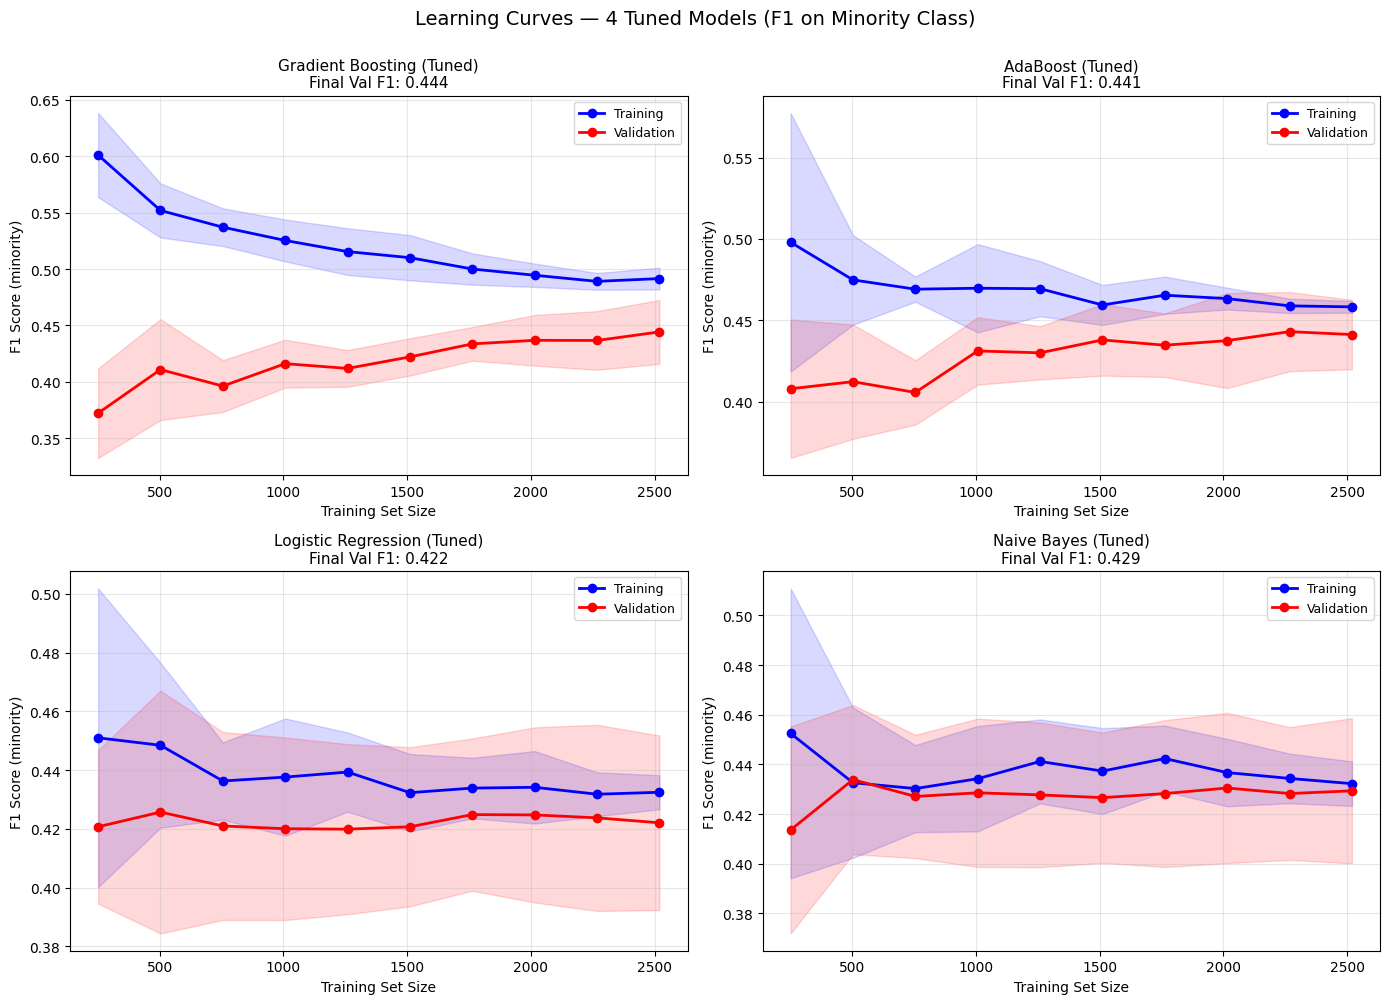


Done. What to look for (vs untuned baseline plots):
  - Did the train-val gap shrink? → tuning reduced overfitting
  - Did the red line (val) rise?  → tuning improved generalization
  - Did both lines move together? → tuning changed bias-variance balance
  - Lines still far apart?        → model limit reached; more data /
                                     richer features would help most


In [78]:
# ======================================================================
# LEARNING CURVES — 4 TUNED MODELS (Phase 2 best hyperparameters)
# F1 on minority class, SMOTE inside pipeline (leakage-safe)
# ======================================================================
# Purpose: Visualize how each TUNED model's F1 improves (or plateaus)
#   as the training set size grows. Direct comparison to the untuned
#   baseline learning curves — shows whether tuning actually changed
#   the generalization structure of each model.
#
# Models: Gradient Boosting, AdaBoost, Logistic Regression, Naive Bayes
#   (each instantiated with Phase 2 best hyperparameters)
#
# Methodology:
#   - Input: X_train_selected + y_train (PRE-SMOTE, 3149 rows)
#   - SMOTE inside ImbPipeline → applied per-fold, leakage-safe
#   - 5-fold stratified CV at each training size
#   - Metric: F1 on minority class (at default 0.50 threshold —
#       threshold tuning is a separate downstream step, not part
#       of the learning curve shape)
#   - 10 training sizes from 10% to 100% of training data
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ---- Define the 4 tuned models with Phase 2 best hyperparameters ----
tuned_models_for_lc = {
    'Gradient Boosting':   GradientBoostingClassifier(**gb_best_params,  random_state=42),
    'AdaBoost':            AdaBoostClassifier(**ada_best_params, random_state=42),
    'Logistic Regression': LogisticRegression(**lr_best_params, random_state=42, max_iter=5000),
    'Naive Bayes':         GaussianNB(**nb_best_params),
}

# ---- Learning curve configuration ----
train_sizes_frac = np.linspace(0.1, 1.0, 10)  # 10 points from 10% to 100%
cv_splitter      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Set up the plot: 2 rows × 2 columns for the 4 tuned models ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("=" * 70)
print("LEARNING CURVES — 4 TUNED MODELS (F1, minority class)")
print("=" * 70)
print(f"Input            : X_train_selected {X_train_selected.shape}, y_train {y_train.shape}")
print(f"CV               : 5-fold stratified, shuffle=True, random_state=42")
print(f"SMOTE            : inside pipeline, per-fold only")
print(f"Training sizes   : {len(train_sizes_frac)} points from 10% to 100%")
print(f"Metric           : F1 on minority class (default thr=0.50)")
print("-" * 70)

# ---- Generate learning curve for each tuned model ----
for idx, (name, model) in enumerate(tuned_models_for_lc.items()):
    print(f"  [{idx+1}/4] Computing learning curve for {name} (tuned)...")

    # Wrap in ImbPipeline so SMOTE is applied per-fold, not globally
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model),
    ])

    # sklearn's learning_curve handles the progressive training + CV
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator    = pipeline,
        X            = X_train_selected,
        y            = y_train,
        train_sizes  = train_sizes_frac,
        cv           = cv_splitter,
        scoring      = 'f1',          # F1 on minority class
        n_jobs       = -1,
        random_state = 42,
        shuffle      = True,
    )

    # Compute mean ± std across the 5 CV folds at each training size
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # ---- Plot ----
    ax = axes[idx]
    ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training', linewidth=2)
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='blue')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='red', label='Validation', linewidth=2)
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='red')

    ax.set_title(f"{name} (Tuned)\nFinal Val F1: {val_mean[-1]:.3f}", fontsize=11)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1 Score (minority)")
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curves — 4 Tuned Models (F1 on Minority Class)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Done. What to look for (vs untuned baseline plots):")
print("=" * 70)
print("  - Did the train-val gap shrink? → tuning reduced overfitting")
print("  - Did the red line (val) rise?  → tuning improved generalization")
print("  - Did both lines move together? → tuning changed bias-variance balance")
print("  - Lines still far apart?        → model limit reached; more data /")
print("                                     richer features would help most")